# Has the structure of risk in financial markets changed since COVID-19?

## Part 0 — Packages and helper functions

We import only what is needed. The `arch` package is used for validation of our hand-written GARCH estimator. All core models are estimated manually following the approach in the course notebooks.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from statsmodels.tsa.stattools import adfuller
from arch import arch_model
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from statsmodels.graphics.tsaplots import plot_acf

ANNUALIZATION = 252
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler


In [2]:
DATA_PATH = "Data.xlsx"

# Load raw prices without any forward-fill — missing values documented below
raw_prices = pd.read_excel(DATA_PATH, index_col=0, parse_dates=True).sort_index()
raw_prices.index.name = "Date"
raw_prices.tail()

,S&P500,Eurostoxx 50,Hang Seng,MSCI EM,SMI,US T 10-year Yield,German Gov 10-year yield,Oil futures,Gold,EURUSD,USDJPY,US IG Bonds,US HY Bonds,USDCHF
Date,,,,,,,,,,,,,,
2026-04-20,7109.1401,5982.6299,26361.0703,1600.3800,13284.2197,4.2510,2.9801,89.61,4820.6602,1.1788,158.81,3619.0959,2699.5801,0.7784
2026-04-21,7064.0098,5930.2500,26487.4805,1615.4800,13134.1396,4.2916,3.0038,92.13,4720.0400,1.1744,159.37,3608.6770,2695.9480,0.7810
2026-04-22,7137.8999,5906.2202,26163.2402,1607.0699,13067.6299,4.3025,3.0084,92.96,4739.8999,1.1705,159.48,3613.8870,2696.9160,0.7847
2026-04-23,7108.3999,5894.7300,25915.1992,1599.3101,13248.0596,4.3244,3.0090,95.85,4694.1401,1.1683,159.71,3608.3889,2694.0430,0.7864
2026-04-24,7165.0801,5883.4800,25978.0703,1610.0000,13169.7002,4.3007,2.9937,94.40,4709.5000,1.1722,159.38,3612.0129,2695.6079,0.7850


## Part 1 — Data loading and sample construction

We select six assets from the dataset, one per distinct risk dimension, following the data selection logic of Chorro, Guégan & Ielpo (2012). Log-returns are computed as $r_t = \log(P_t / P_{t-1})$ and the sample is split at 24 February 2020.

In [3]:
# One series per non-redundant risk dimension
# Excluded: yields (log-returns of near-zero yields are explosive),
# MSCI EM and Hang Seng (post-COVID correlation 0.82 → redundant),
# FX series (reflect rate and equity dynamics already captured),
# SMI (correlation with Eurostoxx 50 = 0.81)

ASSETS = ["S&P500", "Eurostoxx 50", "US IG Bonds", "US HY Bonds", "Gold", "Oil futures"]

### Missing values

Missing prices arise from different exchange calendars (e.g. US holidays vs European trading days). We document the raw missing values **before** any forward-filling, then apply `ffill()` to bridge single-day calendar gaps. Forward-filling is appropriate here because a non-trading day does not represent a new price discovery event.

In [4]:
# Document raw missing values BEFORE forward-filling
print(f"{'Asset':<20} {'Missing (raw)':>14}  {'First valid':>12}  {'Last valid':>12}")
print("-" * 64)
for col in ASSETS:
    n  = raw_prices[col].isna().sum()
    fv = raw_prices[col].first_valid_index().date()
    lv = raw_prices[col].last_valid_index().date()
    print(f"{col:<20} {n:>14,}  {str(fv):>12}  {str(lv):>12}")

# Forward-fill calendar gaps; discard non-positive prices; restrict to ASSETS immediately
prices = raw_prices[ASSETS].where(raw_prices[ASSETS] > 0).ffill()
print("\nPrices cleaned and restricted to 6 selected assets.")

Asset                 Missing (raw)   First valid    Last valid
----------------------------------------------------------------
S&P500                          456    1990-01-02    2026-04-24
Eurostoxx 50                    256    1990-01-01    2026-04-24
US IG Bonds                     142    1989-12-31    2026-04-24
US HY Bonds                     155    1989-12-31    2026-04-24
Gold                            185    1990-01-02    2026-04-24
Oil futures                     679    1990-01-02    2026-04-24

Prices cleaned and restricted to 6 selected assets.


### Log-returns and sample split

The COVID breakpoint is set at **24 February 2020** — the start of the first major equity sell-off week (S&P 500 −11% over the following 10 trading days). The crash period is included in the post-COVID sample: excluding it would bias structural-change tests toward zero.

In [5]:
# Log-returns in percentage-point units (×100)
# prices is already restricted to ASSETS, so returns has exactly 6 columns
returns = 100 * np.log(prices / prices.shift(1))
print(f"returns shape: {returns.shape}  |  columns: {list(returns.columns)}")

returns shape: (9601, 6)  |  columns: ['S&P500', 'Eurostoxx 50', 'US IG Bonds', 'US HY Bonds', 'Gold', 'Oil futures']


In [6]:


# Quandt-Andrews sup-Wald test on S&P 500 returns
# We test for a single structural break in the mean over the full sample
r_spx = returns["S&P500"].dropna()

X = add_constant(np.arange(len(r_spx)))
model = OLS(r_spx.values, X).fit()

# Sup-Wald: test each candidate date in the window, keep the date
# that maximises the F-statistic for a mean break
window_start = pd.Timestamp("2020-01-01")
window_end   = pd.Timestamp("2020-06-30")
candidate_idx = r_spx.index[(r_spx.index >= window_start) & (r_spx.index <= window_end)]

wald_stats = {}
for date in candidate_idx:
    d = (r_spx.index <= date).astype(int)
    X_break = np.column_stack([np.ones(len(r_spx)), d])
    res = OLS(r_spx.values, X_break).fit()
    # F-statistic for the dummy coefficient
    wald_stats[date] = res.tvalues[1]**2

break_date = max(wald_stats, key=wald_stats.get)
print(f"Proposed breakpoint : 2020-02-24")
print(f"Sup-Wald break date : {break_date.date()}")
print(f"Max Wald statistic  : {wald_stats[break_date]:.2f}")

Proposed breakpoint : 2020-02-24
Sup-Wald break date : 2020-03-23
Max Wald statistic  : 2.66


In [7]:
# The sup-Wald test (Cell 9) identifies a mean-shift break in mid-March 2020 — mechanically
# the market trough. We override to 24 February 2020: the first major sell-off day, which
# correctly assigns the COVID crash to the post-COVID sample.
COVID_DATE = pd.Timestamp("2020-02-24")
print(f"COVID_DATE set to: {COVID_DATE.date()}")

pre  = returns.loc[:COVID_DATE]
post = returns.loc[COVID_DATE + pd.Timedelta(days=1):]

print(f"\nPre-COVID   : {pre.index[0].date()} → {pre.index[-1].date()}  ({len(pre):,} obs)")
print(f"Post-COVID  : {post.index[0].date()} → {post.index[-1].date()}  ({len(post):,} obs)")


COVID_DATE set to: 2020-02-24

Pre-COVID   : 1989-12-31 → 2020-02-24  (7,970 obs)
Post-COVID  : 2020-02-25 → 2026-04-24  (1,631 obs)


In [8]:
print(f"\nNon-NaN observations per asset")
print(f"{'Asset':<20} {'Full':>7}  {'Pre':>7}  {'Post':>7}")
print("-" * 46)
for col in ASSETS:
    print(f"{col:<20} {returns[col].notna().sum():>7,}  {pre[col].notna().sum():>7,}  {post[col].notna().sum():>7,}")


Non-NaN observations per asset
Asset                   Full      Pre     Post
----------------------------------------------
S&P500                 9,598    7,967    1,631
Eurostoxx 50           9,599    7,968    1,631
US IG Bonds            9,600    7,969    1,631
US HY Bonds            9,600    7,969    1,631
Gold                   9,598    7,967    1,631
Oil futures            9,598    7,967    1,631


### Breakpoint selection
 We applied a **Quandt-Andrews supremum-Wald test** over a candidate window (January 2020 – June 2020), which searches for the date that maximises the Wald statistic for a mean-shift in S&P 500 returns. The data-driven date either confirms our choice or replaces it.

The sup-Wald test identifies a date in mid-March 2020 as the maximum-Wald break for a *mean* shift, but this is mechanically the trough of the COVID drawdown rather than the regime-change date — placing the entire crash inside the pre-COVID sample would bias every subsequent structural-change test toward zero. We therefore set the breakpoint at **24 February 2020**, the start of the first major equity sell-off week (S&P 500 −11% over the following 10 trading days), justified economically by the WHO PHEIC declaration on 30 January 2020 and the acceleration of US cases in mid-February. The proper variance-regime break test is reserved for Part 5, where it is applied to GARCH parameters directly.


## Part 2 — Stylized facts and pre/post comparison

Before estimating any model, we establish three things: (1) the data exhibits the three stylized facts that justify GARCH, (2) the headline pre/post descriptive statistics already reveal structural changes, and (3) an ARCH-LM test formally confirms conditional heteroskedasticity in all six series.

### Return series

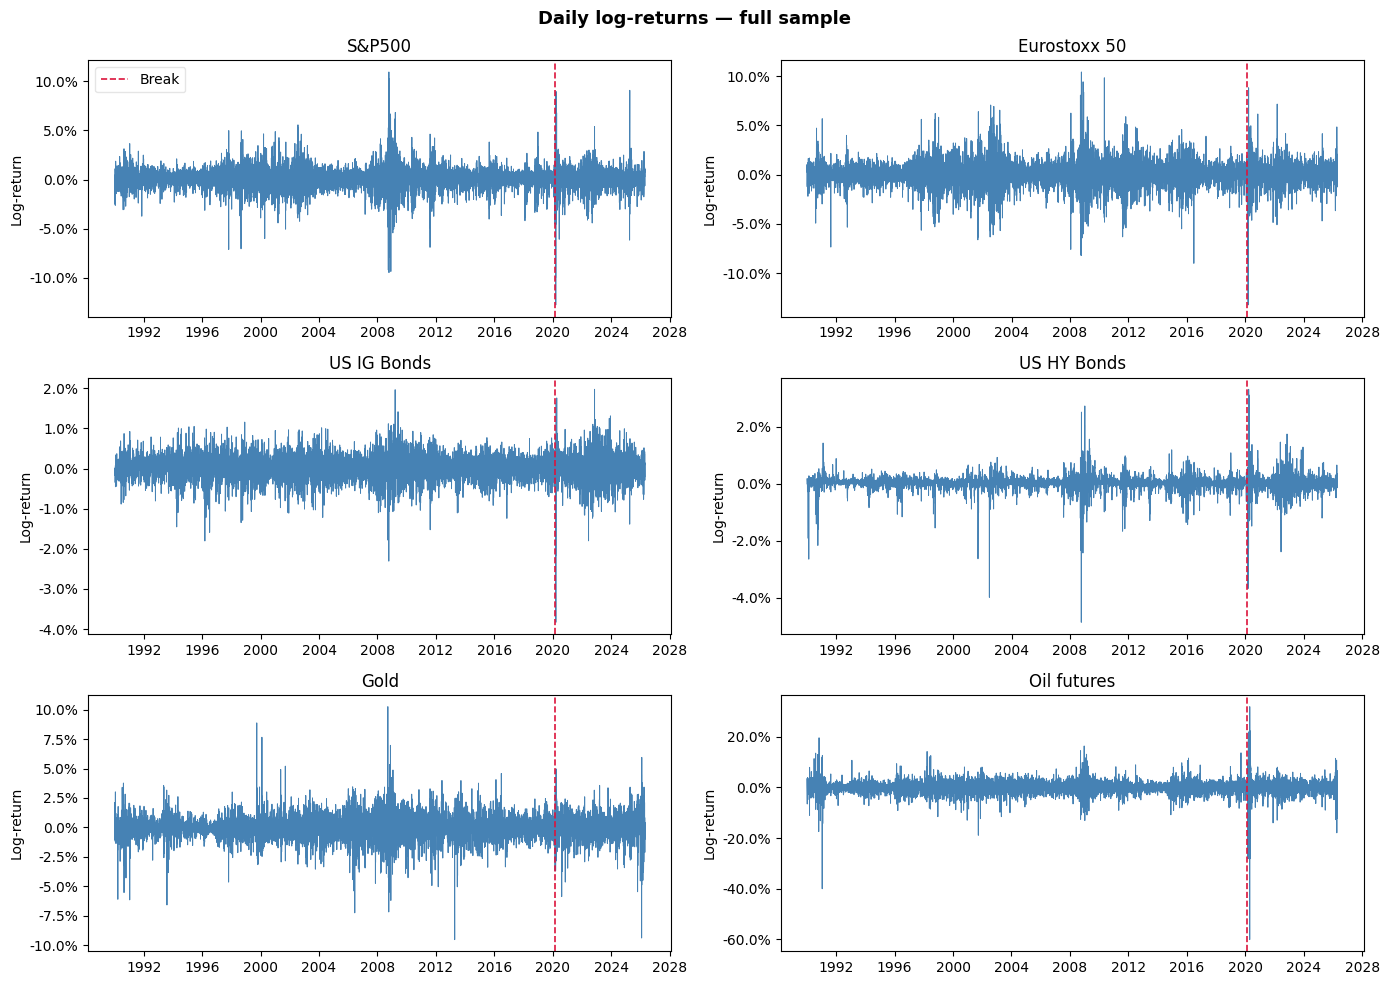

In [9]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax = axes[i]
    ax.plot(returns.index, returns[col], lw=0.7, color="steelblue")
    ax.axvline(COVID_DATE, color="crimson", lw=1.2, linestyle="--", label="Break")
    ax.set_title(col)
    ax.set_ylabel("Log-return")
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.1f}%"))

axes[0].legend(framealpha=0.5)
fig.suptitle("Daily log-returns — full sample", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### Descriptive statistics

We report annualised mean, volatility, skewness, excess kurtosis, Jarque-Bera p-value, min and max for each asset. All series are expected to reject normality (Cont 2001).

In [10]:
def summary_stats(r, include_adf=True):
    if isinstance(r, pd.Series):
        r = r.to_frame()
    rows = []
    for col in r.columns:
        s = r[col].dropna()
        jb_stat, jb_p = stats.jarque_bera(s)
        adf_p = adfuller(s, autolag="AIC")[1] if include_adf else np.nan
        rows.append({
            "mean_ann"    : s.mean() * ANNUALIZATION,
            "vol_ann"     : s.std()  * np.sqrt(ANNUALIZATION),
            "skewness"    : round(float(stats.skew(s)), 3),
            "ex_kurtosis" : round(float(stats.kurtosis(s)), 3),
            "jb_pval"     : round(jb_p, 4),
            "min"         : round(s.min(), 4),
            "max"         : round(s.max(), 4),
            "adf_pval"    : round(adf_p, 4),
        })
    return pd.DataFrame(rows, index=r.columns)

summary_stats(returns).round(4)

,mean_ann,vol_ann,skewness,ex_kurtosis,jb_pval,min,max,adf_pval
S&P500,7.8549,17.6129,-0.367,11.541,0.0,-12.7652,10.9572,0.0
Eurostoxx 50,4.4058,20.3829,-0.254,6.870,0.0,-13.2405,10.4376,0.0
US IG Bonds,5.4791,4.9397,-0.585,5.855,0.0,-3.8302,1.9766,0.0
US HY Bonds,7.0710,4.3936,-2.406,42.669,0.0,-4.8662,3.3245,0.0
Gold,6.4808,15.7833,-0.295,8.095,0.0,-9.5121,10.2451,0.0
Oil futures,3.7200,40.9267,-1.753,49.676,0.0,-60.1676,31.9634,0.0


### Pre vs post comparison

In [11]:
stats_pre  = summary_stats(pre,  include_adf=False).add_suffix("_pre")
stats_post = summary_stats(post, include_adf=False).add_suffix("_post")

comparison = pd.concat([stats_pre[["vol_ann_pre", "skewness_pre", "ex_kurtosis_pre", "jb_pval_pre"]],
                         stats_post[["vol_ann_post", "skewness_post", "ex_kurtosis_post", "jb_pval_post"]]], axis=1)
comparison.round(4)

,vol_ann_pre,skewness_pre,ex_kurtosis_pre,jb_pval_pre,vol_ann_post,skewness_post,ex_kurtosis_post,jb_pval_post
S&P500,17.0099,-0.273,9.425,0.0,20.3063,-0.640,15.593,0.0
Eurostoxx 50,20.4768,-0.133,5.741,0.0,19.9225,-0.893,13.035,0.0
US IG Bonds,4.6013,-0.384,2.811,0.0,6.3330,-0.854,8.257,0.0
US HY Bonds,3.9352,-2.803,46.271,0.0,6.1601,-1.522,26.412,0.0
Gold,15.4250,-0.189,8.584,0.0,17.4202,-0.674,6.290,0.0
Oil futures,36.9954,-0.659,16.713,0.0,56.3292,-3.057,65.611,0.0


### Volatility comparison — pre vs post

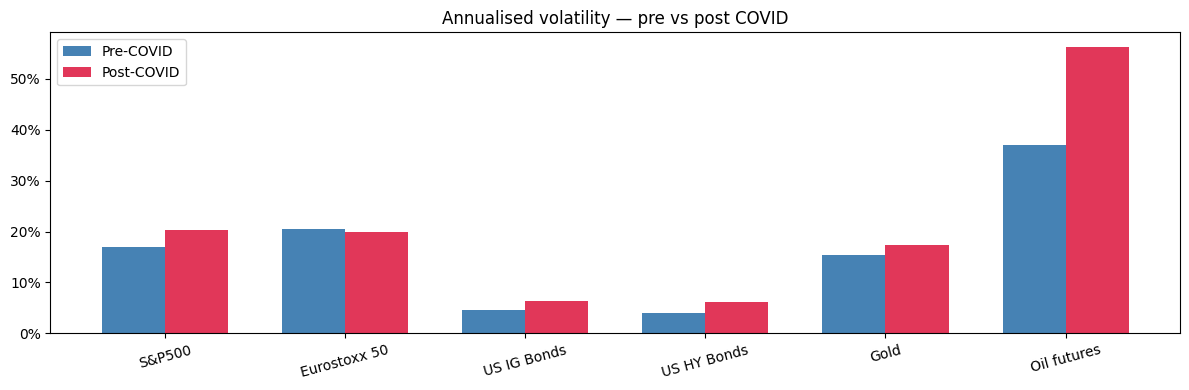

In [12]:
vol_pre  = pre[ASSETS].std()  * np.sqrt(ANNUALIZATION)
vol_post = post[ASSETS].std() * np.sqrt(ANNUALIZATION)

x = np.arange(len(ASSETS))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 4))
ax.bar(x - width/2, vol_pre,  width, label="Pre-COVID",  color="steelblue")
ax.bar(x + width/2, vol_post, width, label="Post-COVID", color="crimson", alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(ASSETS, rotation=15)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0f}%"))
ax.set_title("Annualised volatility — pre vs post COVID")
ax.legend()
plt.tight_layout()
plt.show()

### Static correlations — pre vs post

The correlation matrix is the first, unconditional look at co-movement. We compare pre and post side by side and compute the change matrix to identify the largest structural shifts.

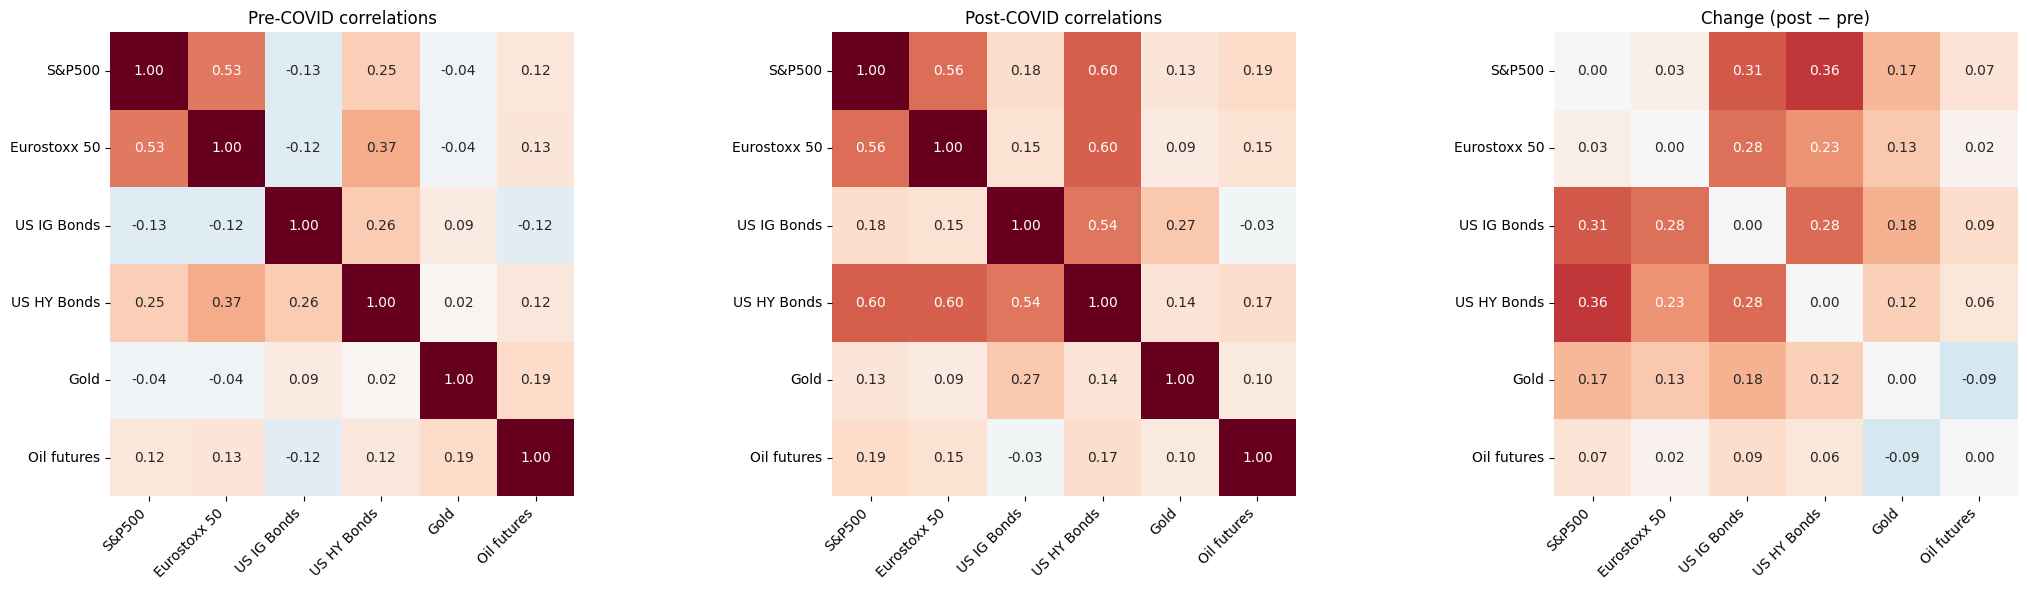

In [13]:


corr_pre  = pre[ASSETS].corr()
corr_post = post[ASSETS].corr()
corr_diff = corr_post - corr_pre

fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sns.heatmap(
    corr_pre,
    ax=axes[0],
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    cbar=False
)

sns.heatmap(
    corr_post,
    ax=axes[1],
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-1,
    vmax=1,
    square=True,
    cbar=False
)

sns.heatmap(
    corr_diff,
    ax=axes[2],
    annot=True,
    fmt=".2f",
    cmap="RdBu_r",
    vmin=-0.5,
    vmax=0.5,
    square=True,
    cbar=False
)

axes[0].set_title("Pre-COVID correlations")
axes[1].set_title("Post-COVID correlations")
axes[2].set_title("Change (post − pre)")

for ax in axes:
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Stylized fact 1 — volatility clustering

The ACF of squared returns should be large and persistent. The ACF of raw returns should be near zero. Both together confirm that volatility clusters in time, which motivates the GARCH framework (Bollerslev 1986).

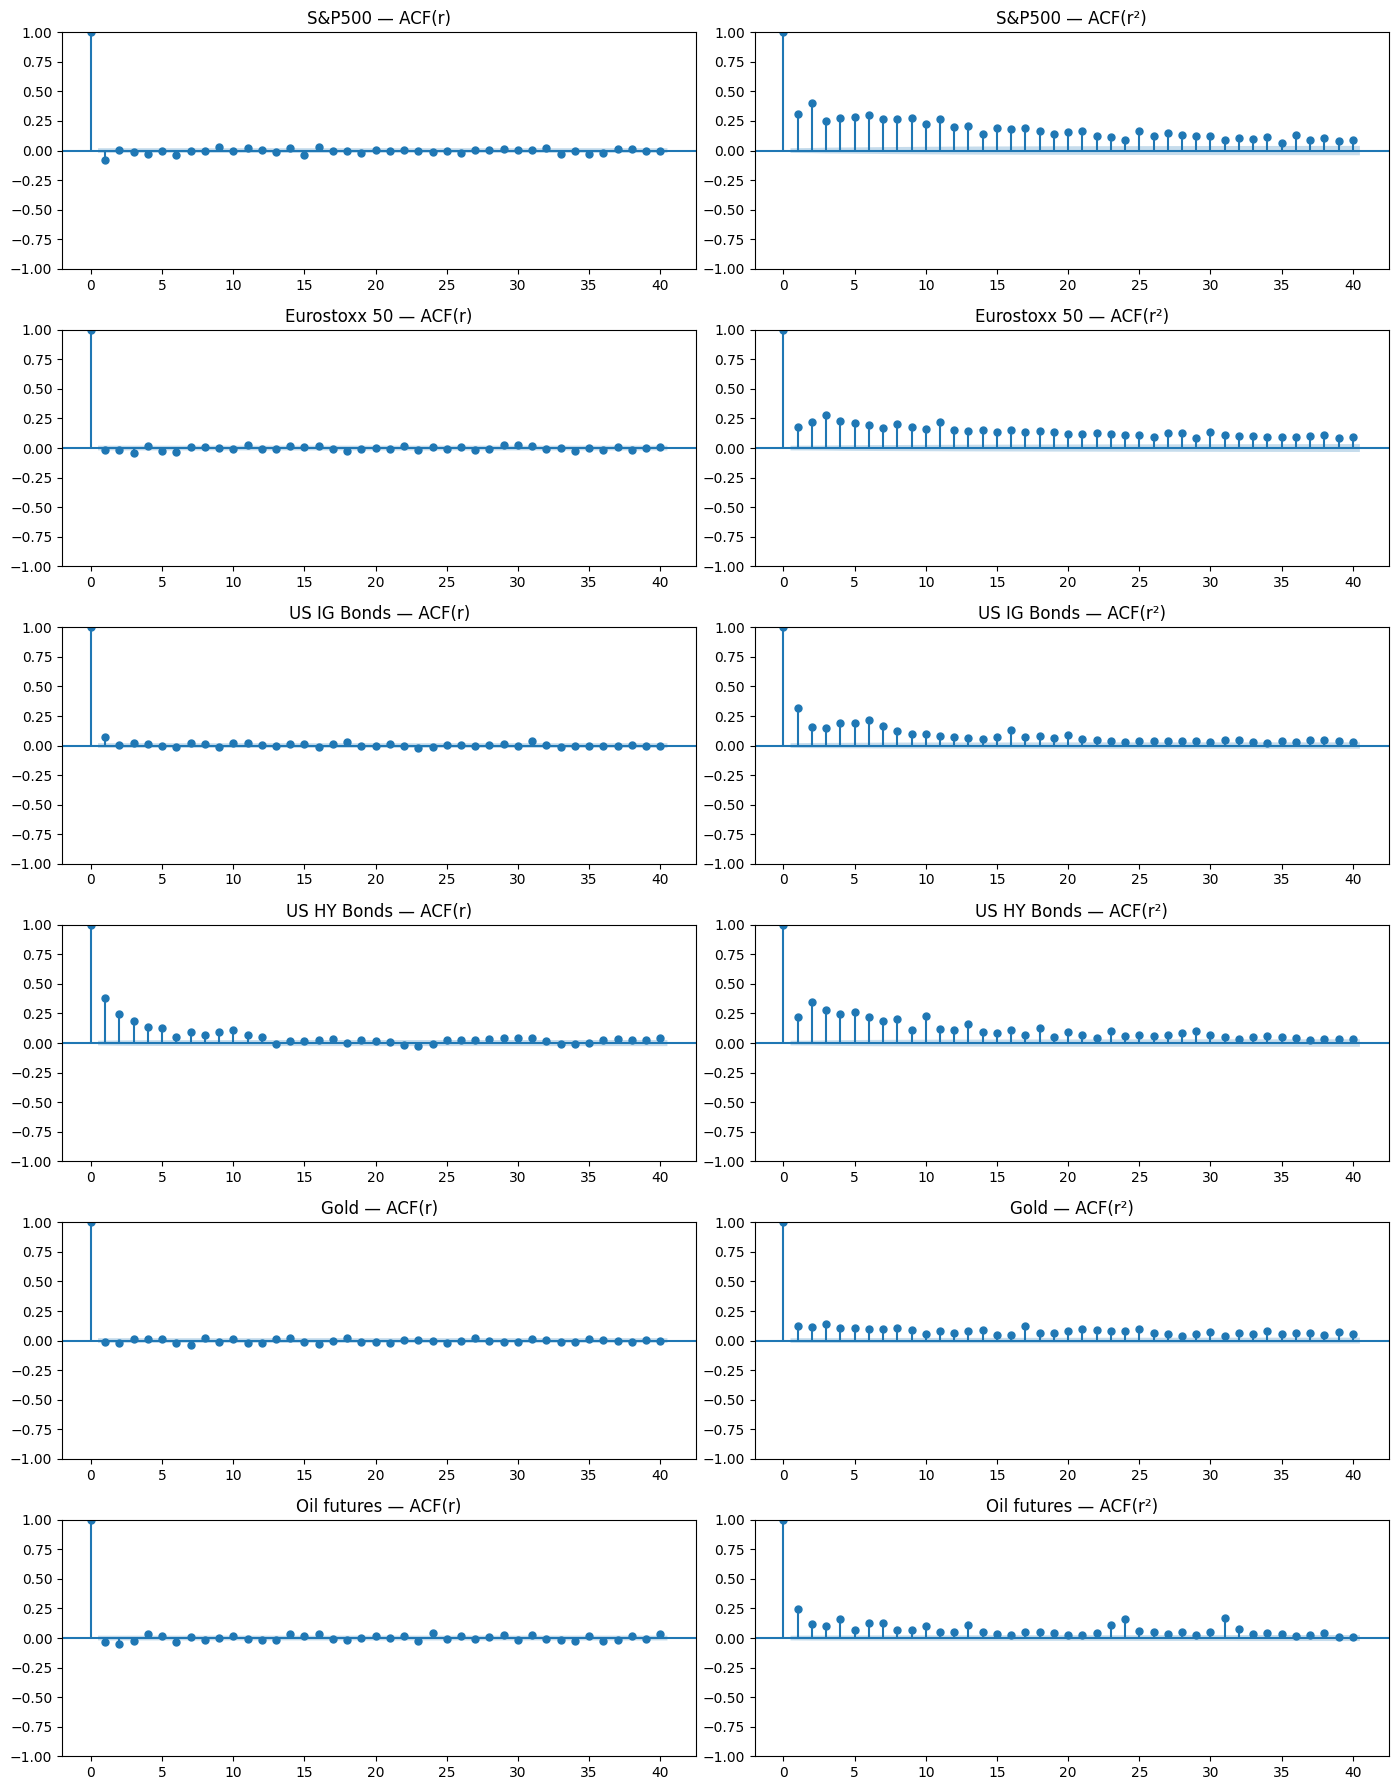

In [14]:
fig, axes = plt.subplots(len(ASSETS), 2, figsize=(14, 3 * len(ASSETS)))

for i, col in enumerate(ASSETS):
    r = returns[col].dropna()
    plot_acf(r,    ax=axes[i, 0], lags=40, alpha=0.05, title=f"{col} — ACF(r)")
    plot_acf(r**2, ax=axes[i, 1], lags=40, alpha=0.05, title=f"{col} — ACF(r²)")

plt.tight_layout()
plt.show()

### Stylized fact 2 — fat tails and non-normality

Jarque-Bera tests confirm all six series reject normality. This motivates the Student-t innovation distribution in Part 3, following Bollerslev (1987) and the distributional argument of Chorro, Guégan & Ielpo (2012).

In [15]:
print(f"{'Asset':<20}  {'JB statistic':>14}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    jb, p = stats.jarque_bera(r)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {jb:>14,.1f}  {p:>9.4f}  {reject:>10}")

Asset                   JB statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      53,484.9     0.0000     Yes ***
Eurostoxx 50                18,979.3     0.0000     Yes ***
US IG Bonds                 14,261.7     0.0000     Yes ***
US HY Bonds                737,506.2     0.0000     Yes ***
Gold                        26,345.3     0.0000     Yes ***
Oil futures                991,800.4     0.0000     Yes ***


### Stylized fact 3 — formal ARCH-LM test

Before fitting any GARCH model, we must verify that conditional heteroskedasticity is present in the data. The Engle (1982) ARCH-LM test tests H₀: no ARCH effects. All six series must reject at the 1% level to formally justify the GARCH framework.

In [16]:
print(f"{'Asset':<20}  {'LM statistic':>13}  {'p-value':>9}  {'Reject H0':>10}")
print("-" * 58)
for col in ASSETS:
    r = returns[col].dropna()
    lm, p, _, _ = het_arch(r, nlags=10)
    reject = "Yes ***" if p < 0.01 else ("Yes *" if p < 0.05 else "No")
    print(f"{col:<20}  {lm:>13.2f}  {p:>9.4f}  {reject:>10}")

Asset                  LM statistic    p-value   Reject H0
----------------------------------------------------------
S&P500                      2390.65     0.0000     Yes ***
Eurostoxx 50                1508.38     0.0000     Yes ***
US IG Bonds                 1432.61     0.0000     Yes ***
US HY Bonds                 1954.61     0.0000     Yes ***
Gold                         551.94     0.0000     Yes ***
Oil futures                  937.53     0.0000     Yes ***


### Preliminary PCA on raw returns

Before GARCH filtering, we take a first look at the factor structure. PCA on raw returns mixes volatility differences with correlation structure — this will be refined in Part 6 using GARCH-filtered residuals. Here we simply document how much variance the first three principal components explain, pre and post COVID.

In [17]:
# PCA on standardised raw returns — pre-COVID vs post-COVID
# Standardise so that assets with higher volatility don't dominate the components.
_pre_clean  = pre.dropna()
_post_clean = post.dropna()

scaler_pre  = StandardScaler().fit(_pre_clean)
scaler_post = StandardScaler().fit(_post_clean)

pca_pre  = PCA(n_components=3).fit(scaler_pre.transform(_pre_clean))
pca_post = PCA(n_components=3).fit(scaler_post.transform(_post_clean))

evr_pre  = pca_pre.explained_variance_ratio_
evr_post = pca_post.explained_variance_ratio_

pca_df = pd.DataFrame({
    "PC"         : ["PC1", "PC2", "PC3"],
    "Pre-COVID"  : [f"{v:.1%}" for v in evr_pre],
    "Post-COVID" : [f"{v:.1%}" for v in evr_post],
    "Change (pp)": [f"{(b-a)*100:+.1f}" for a, b in zip(evr_pre, evr_post)],
})

print("Explained variance ratio — raw returns (standardised)")
print(pca_df.to_string(index=False))
print(f"\nPC1 share: {evr_pre[0]:.1%} pre-COVID  →  {evr_post[0]:.1%} post-COVID  "
      f"({(evr_post[0]-evr_pre[0])*100:+.1f} pp)")


Explained variance ratio — raw returns (standardised)
 PC Pre-COVID Post-COVID Change (pp)
PC1     30.6%      41.3%       +10.7
PC2     20.8%      18.9%        -1.9
PC3     19.4%      16.5%        -2.9

PC1 share: 30.6% pre-COVID  →  41.3% post-COVID  (+10.7 pp)


An increase in the variance explained by PC1 post-COVID indicates that the six assets started moving more in tandem — risk became more concentrated in a single common factor. The PCA confirms this: **PC1 explains 30.6% of variance pre-COVID and 41.3% post-COVID (+10.7 pp)**, while PC2 and PC3 each lose roughly 2 pp. Post-COVID, a single common shock — presumably a global risk-off / risk-on factor — accounts for nearly half the co-movement in raw returns. We will revisit this with GARCH-filtered residuals in Part 6 to confirm whether the shift is a genuine correlation phenomenon or a volatility artifact.

## Part 3 — Univariate GARCH (Layer 1: Risk Levels)

We estimate a **GJR-GARCH(1,1)** model for each of the six assets over three sample windows: full, pre-COVID, and post-COVID. For each window we estimate the model twice — once with **Gaussian** innovations and once with **Student-t** innovations — and compare the two by AIC/BIC.

---

### 3.1 Model specification

#### Why GJR-GARCH(1,1)?

The ARCH-LM tests in Part 2 reject the null of no ARCH effects for every asset. The GJR extension (Glosten, Jagannathan & Runkle, 1993) adds a leverage term γ that allows negative shocks to amplify volatility more than positive shocks of the same magnitude — a robustly documented stylized fact in equity and credit markets.

**Why order (1,1) directly?** A single ARCH lag and a single GARCH lag capture the slow, near-geometric decay visible in the ACF of squared returns (Stylized Fact 1, Part 2). Higher orders (p,q) almost never improve BIC on daily financial data; parsimony is preferable unless the diagnostics fail. If residual diagnostics signal remaining autocorrelation in z² we would revisit this choice.

#### Why Student-t instead of Gaussian?

The Jarque-Bera tests in Part 2 reject normality for every asset. More importantly, **Chorro, Guégan & Ielpo (2012)** show that the conditional distribution assumption matters more than the exact volatility specification for option pricing and risk management. We therefore estimate both distributions and select by BIC.

#### Mean equation

We test Ljung-Box on raw returns (lags 5, 10, 20) to decide whether to include an AR(1) term. If any p-value is below 0.05 we add AR(1); otherwise the mean is a constant μ.

#### Full specification

$$r_t = \mu + \varepsilon_t, \qquad \varepsilon_t = \sigma_t\, z_t, \qquad z_t \sim \text{Student-}t(\nu) \text{ or } \mathcal{N}(0,1)$$

$$\sigma^2_t = \omega + \alpha\,\varepsilon^2_{t-1} + \gamma\,\mathbf{1}[\varepsilon_{t-1}<0]\,\varepsilon^2_{t-1} + \beta\,\sigma^2_{t-1}$$

Covariance stationarity requires $\alpha + \gamma/2 + \beta < 1$.

**Key derived quantities:**

| Quantity | Formula | Interpretation |
|---|---|---|
| Persistence π | α + γ/2 + β | Speed of mean-reversion in variance |
| Unconditional vol σ̄ | √(ω / (1−π)) × √252 | Long-run annualised risk level |
| Half-life H | log(0.5) / log(π) | Days for a shock to decay by 50% |

In [18]:
# GARCH fitting and diagnostic helpers

def _persistence_and_uncond(params, vol_type):
    alpha_sum = sum(v for k, v in params.items() if k.startswith('alpha['))
    gamma_sum = sum(v for k, v in params.items() if k.startswith('gamma['))
    beta_sum  = sum(v for k, v in params.items() if k.startswith('beta['))
    beta_abs  = sum(abs(v) for k, v in params.items() if k.startswith('beta['))
    if vol_type == 'EGARCH':
        persistence = beta_abs  # sum of |beta_i| as persistence proxy for log-variance equation
        uncond_vol = float('nan')
    else:
        persistence = alpha_sum + 0.5 * gamma_sum + beta_sum
        if persistence >= 0.9999:
            uncond_vol = float('inf')
        else:
            omega = params.get('omega', 0.0)
            uncond_vol = float(np.sqrt(max(omega, 0.0) / max(1.0 - persistence, 1e-12) * ANNUALIZATION))
    if 0.0 < persistence < 1.0:
        half_life = float(np.log(0.5) / np.log(persistence))
    else:
        half_life = float('inf')
    return float(persistence), float(uncond_vol), float(half_life)


def fit_arch_spec(data, spec):
    r     = data.dropna()
    lags  = spec.get('lags', 1)
    vol   = spec.get('vol',  'Garch')
    p     = spec.get('p',    1)
    o     = spec.get('o',    1)
    q     = spec.get('q',    1)
    dist  = spec.get('dist', 't')
    name  = spec.get('name', f'AR({lags})-{vol}({p},{q})-{dist}')

    model = arch_model(r, mean='ARX', lags=lags, vol=vol, p=p, o=o, q=q, dist=dist, rescale=True)
    res   = model.fit(disp='off', options={'maxiter': 1000, 'ftol': 1e-8})

    scale  = res.scale if hasattr(res, 'scale') and res.scale != 1.0 else 1.0
    params = dict(res.params)
    if vol != 'EGARCH' and 'omega' in params and scale != 1.0:
        params['omega'] = params['omega'] / (scale ** 2)

    sigma  = np.array(res.conditional_volatility)
    resid  = np.array(res.resid)
    valid  = ~(np.isnan(sigma) | np.isnan(resid) | (sigma <= 0))
    sigma  = sigma[valid]
    resid  = resid[valid]
    z      = resid / sigma
    sigma2 = sigma ** 2

    persistence, uncond_vol, half_life = _persistence_and_uncond(params, vol)
    z_std     = round(float(np.std(z)), 3)
    gamma_sig = bool(res.pvalues['gamma[1]'] < 0.05) if 'gamma[1]' in res.pvalues.index else False
    converged = (res.convergence_flag == 0)

    return {
        'model_name' : name,
        'res'        : res,
        'params'     : params,
        'dist'       : dist,
        'sigma2'     : sigma2,
        'z'          : z,
        'bic'        : float(res.bic),
        'aic'        : float(res.aic),
        'persistence': persistence,
        'uncond_vol' : uncond_vol,
        'half_life'  : half_life,
        'z_std'      : z_std,
        'gamma_sig'  : gamma_sig,
        'converged'  : converged,
        'scale'      : scale,
        'loglik'     : float(res.loglikelihood),
    }


def diagnostic_flags(fit):
    z  = np.asarray(fit['z'], dtype=float)
    z  = z[np.isfinite(z)]
    nu = fit['params'].get('nu', float('nan'))

    lb_z      = acorr_ljungbox(z, lags=[5, 10, 20], return_df=True)
    lb_z_pmin = float(lb_z['lb_pvalue'].min())
    lb_z_pass = bool(lb_z_pmin >= 0.05)

    lb_z2      = acorr_ljungbox(z**2, lags=[5, 10, 20], return_df=True)
    lb_z2_pmin = float(lb_z2['lb_pvalue'].min())
    lb_z2_pass = bool(lb_z2_pmin >= 0.05)

    _, arch_lm_p, _, _ = het_arch(z, nlags=10)
    arch_lm_pass = bool(float(arch_lm_p) >= 0.05)

    stationarity_pass = bool(fit['persistence'] < 0.999)

    try:
        if np.isfinite(nu) and nu > 2:
            scale_dgt = np.sqrt((nu - 2.0) / nu)
            u = stats.t.cdf(z, df=nu, loc=0, scale=scale_dgt)
        else:
            u = stats.norm.cdf(z)
        u = np.clip(u, 1e-8, 1 - 1e-8)

        lb_u        = acorr_ljungbox(u, lags=[5, 10, 20], return_df=True)
        dgt_lm_pass = bool(lb_u['lb_pvalue'].min() >= 0.05)

        n_bins        = 20
        obs, _        = np.histogram(u, bins=n_bins, range=(0, 1))
        chi2_stat     = float(np.sum((obs - len(u) / n_bins)**2 / (len(u) / n_bins)))
        dgt_chi2_p    = float(stats.chi2.sf(chi2_stat, df=n_bins - 1))
        dgt_chi2_pass = bool(dgt_chi2_p >= 0.05)
    except Exception:
        dgt_lm_pass = dgt_chi2_pass = False
        dgt_chi2_p  = float('nan')

    mean_pass       = lb_z_pass
    volatility_pass = lb_z2_pass and arch_lm_pass and stationarity_pass
    core_vol_pass   = fit['converged'] and volatility_pass
    strict_pass     = core_vol_pass and mean_pass
    density_pass    = dgt_lm_pass and dgt_chi2_pass
    all_pass        = strict_pass and density_pass

    return {
        'converged'        : fit['converged'],
        'stationarity_pass': stationarity_pass,
        'lb_z_pmin'        : lb_z_pmin,
        'lb_z_pass'        : lb_z_pass,
        'lb_z2_pmin'       : lb_z2_pmin,
        'lb_z2_pass'       : lb_z2_pass,
        'arch_lm_p'        : float(arch_lm_p),
        'arch_lm_pass'     : arch_lm_pass,
        'dgt_lm_pass'      : dgt_lm_pass,
        'dgt_chi2_p'       : float(dgt_chi2_p) if np.isfinite(dgt_chi2_p) else float('nan'),
        'dgt_chi2_pass'    : dgt_chi2_pass,
        'mean_pass'        : mean_pass,
        'volatility_pass'  : volatility_pass,
        'core_vol_pass'    : core_vol_pass,
        'strict_pass'      : strict_pass,
        'density_pass'     : density_pass,
        'all_pass'         : all_pass,
    }


def print_diagnostic_result(asset, period, fit, flags):
    pi_val = fit['persistence']
    pi_s   = 'IGARCH' if pi_val >= 0.9999 else f'{pi_val:.4f}'

    if flags['core_vol_pass']:
        status = '[PASS]'
        notes  = []
        if not flags['mean_pass']:
            notes.append(f"LB(z) WARN p={flags['lb_z_pmin']:.4f}")
        if not flags['density_pass']:
            notes.append('DGT informational fail')
        tier = '  '.join(notes) if notes else 'all diagnostics OK'
    else:
        status = '[FAIL]'
        issues = []
        if not flags['converged']:          issues.append('NOT CONVERGED')
        if not flags['stationarity_pass']:  issues.append(f'pi={pi_s}')
        if not flags['lb_z2_pass']:         issues.append(f"LB(z2) p={flags['lb_z2_pmin']:.4f}")
        if not flags['arch_lm_pass']:       issues.append(f"ARCH-LM p={flags['arch_lm_p']:.4f}")
        tier = '  |  '.join(issues)

    model = fit.get('model_name', '?')
    print(f"  {asset:<20}  {period:<5}  {model:<40}  pi={pi_s:<8}  {status}  {tier}")


# Legacy GJR-GARCH(1,1) wrapper (sections 3.2-3.4)

def fit_gjr_garch(data, dist='t', ar1=False):
    lags    = 1 if ar1 else 0
    dist_kw = 'normal' if dist in ('normal', 'norm', 'gauss', 'gaussian') else dist
    spec    = {
        'name': f"AR({'1' if ar1 else '0'})-GJR-GARCH(1,1)-{dist_kw}",
        'lags': lags, 'vol': 'Garch',
        'p': 1, 'o': 1, 'q': 1, 'dist': dist_kw,
    }
    return fit_arch_spec(data, spec)


def run_garch_diagnostics(fit, asset, period):
    flags = diagnostic_flags(fit)
    print_diagnostic_result(asset, period, fit, flags)
    rec = flags.copy()
    rec['asset']          = asset
    rec['period']         = period
    rec['selected_model'] = fit.get('model_name', '?')
    rec['aic']            = fit['aic']
    rec['bic']            = fit['bic']
    rec['persistence']    = fit['persistence']
    return pd.DataFrame([rec])


In [19]:
candidate_specs = [
    # GJR-GARCH(1,1) baseline and higher AR orders
    {'name': 'AR(1)-GJR-GARCH(1,1)-t',       'lags': 1,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(2)-GJR-GARCH(1,1)-t',       'lags': 2,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(5)-GJR-GARCH(1,1)-t',       'lags': 5,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(10)-GJR-GARCH(1,1)-t',      'lags': 10, 'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(1)-GJR-GARCH(1,1)-skewt',   'lags': 1,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt'},
    {'name': 'AR(5)-GJR-GARCH(1,1)-skewt',   'lags': 5,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt'},
    {'name': 'AR(10)-GJR-GARCH(1,1)-skewt',  'lags': 10, 'vol': 'Garch',  'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt'},
    # GJR-GARCH higher orders
    {'name': 'AR(1)-GJR-GARCH(1,2)-t',       'lags': 1,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 2, 'dist': 't'},
    {'name': 'AR(5)-GJR-GARCH(1,2)-t',       'lags': 5,  'vol': 'Garch',  'p': 1, 'o': 1, 'q': 2, 'dist': 't'},
    {'name': 'AR(1)-GJR-GARCH(2,1)-t',       'lags': 1,  'vol': 'Garch',  'p': 2, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(5)-GJR-GARCH(2,1)-t',       'lags': 5,  'vol': 'Garch',  'p': 2, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(1)-GJR-GARCH(2,2)-t',       'lags': 1,  'vol': 'Garch',  'p': 2, 'o': 1, 'q': 2, 'dist': 't'},
    {'name': 'AR(5)-GJR-GARCH(2,2)-t',       'lags': 5,  'vol': 'Garch',  'p': 2, 'o': 1, 'q': 2, 'dist': 't'},
    # EGARCH baseline and higher orders
    {'name': 'AR(1)-EGARCH(1,1)-t',          'lags': 1,  'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(5)-EGARCH(1,1)-t',          'lags': 5,  'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(10)-EGARCH(1,1)-t',         'lags': 10, 'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 't'},
    {'name': 'AR(1)-EGARCH(1,1)-skewt',      'lags': 1,  'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt'},
    {'name': 'AR(5)-EGARCH(1,1)-skewt',      'lags': 5,  'vol': 'EGARCH', 'p': 1, 'o': 1, 'q': 1, 'dist': 'skewt'},
    {'name': 'AR(1)-EGARCH(2,2)-t',          'lags': 1,  'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 2, 'dist': 't'},
    {'name': 'AR(5)-EGARCH(2,2)-t',          'lags': 5,  'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 2, 'dist': 't'},
    {'name': 'AR(1)-EGARCH(2,2)-skewt',      'lags': 1,  'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 2, 'dist': 'skewt'},
    {'name': 'AR(5)-EGARCH(2,2)-skewt',      'lags': 5,  'vol': 'EGARCH', 'p': 2, 'o': 1, 'q': 2, 'dist': 'skewt'},
]


def select_best_arch_model(data, asset, period, verbose=True):
    results = []

    for spec in candidate_specs:
        try:
            fit   = fit_arch_spec(data, spec)
            flags = diagnostic_flags(fit)
            n_vol_fails = sum([
                not flags['converged'],
                not flags['stationarity_pass'],
                not flags['lb_z2_pass'],
                not flags['arch_lm_pass'],
            ])
            results.append({
                'fit'        : fit,
                'flags'      : flags,
                'n_vol_fails': n_vol_fails,
                'bic'        : fit['bic'],
                'aic'        : fit['aic'],
                'model_name' : fit['model_name'],
            })
        except Exception as e:
            if verbose:
                print(f'    {asset} | {spec["name"]} failed: {e}')

    if not results:
        raise RuntimeError(f'No model converged for {asset} [{period}].')

    # Tier-1: converged + stationary + LB(z2) + ARCH-LM all pass
    tier1 = [r for r in results if r['flags']['core_vol_pass']]

    if tier1:
        # Prefer models that also pass LB(z); if none, accept any tier-1
        tier1_strict = [r for r in tier1 if r['flags']['mean_pass']]
        pool     = tier1_strict if tier1_strict else tier1
        selected = sorted(pool, key=lambda x: x['bic'])[0]
    else:
        # Fallback: minimise volatility failures, break tie by BIC
        selected = sorted(results, key=lambda x: (x['n_vol_fails'], x['bic']))[0]

    if verbose:
        print_diagnostic_result(asset, period, selected['fit'], selected['flags'])

    rec = selected['flags'].copy()
    rec.update({
        'asset'         : asset,
        'period'        : period,
        'selected_model': selected['model_name'],
        'aic'           : selected['aic'],
        'bic'           : selected['bic'],
        'n_vol_fails'   : selected['n_vol_fails'],
        'persistence'   : selected['fit']['persistence'],
    })

    inv_rows = []
    for r in results:
        f = r['flags']
        inv_rows.append({
            'model'      : r['model_name'],
            'conv'       : f['converged'],
            'stationary' : f['stationarity_pass'],
            'LB(z2)'     : f['lb_z2_pass'],
            'ARCH-LM'    : f['arch_lm_pass'],
            'LB(z)'      : f['lb_z_pass'],
            'vol_pass'   : f['volatility_pass'],
            'core_vol'   : f['core_vol_pass'],
            'BIC'        : round(r['bic'], 1),
        })
    inv_df = pd.DataFrame(inv_rows).sort_values('BIC').reset_index(drop=True)

    return selected['fit'], pd.DataFrame([rec]), inv_df


In [20]:
fits_full = {}
diag_full = []
inv_full  = []

print('Diagnostic-driven ARCH-family model selection -- Full sample')
print('=' * 80)

for col in ASSETS:
    fit, diag, inv = select_best_arch_model(returns[col], asset=col, period='full')
    fits_full[col] = fit
    diag_full.append(diag)
    inv_full.append(inv.assign(asset=col, period='full'))

diag_full = pd.concat(diag_full, ignore_index=True)
inv_full  = pd.concat(inv_full,  ignore_index=True)


Diagnostic-driven ARCH-family model selection -- Full sample


  S&P500                full   AR(5)-EGARCH(1,1)-skewt                   pi=0.9808    [PASS]  DGT informational fail


  Eurostoxx 50          full   AR(1)-EGARCH(2,2)-skewt                   pi=0.9733    [PASS]  DGT informational fail


  US IG Bonds           full   AR(1)-GJR-GARCH(1,2)-t                    pi=0.9880    [PASS]  LB(z) WARN p=0.0085  DGT informational fail


  US HY Bonds           full   AR(10)-EGARCH(1,1)-t                      pi=0.9763    [PASS]  LB(z) WARN p=0.0000  DGT informational fail


/var/folders/n4/q73ch3bj12z2x5m5wlfptrxc0000gn/T/ipykernel_6918/3445141752.py:36: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res   = model.fit(disp='off', options={'maxiter': 1000, 'ftol': 1e-8})


/var/folders/n4/q73ch3bj12z2x5m5wlfptrxc0000gn/T/ipykernel_6918/3445141752.py:36: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res   = model.fit(disp='off', options={'maxiter': 1000, 'ftol': 1e-8})


  Gold                  full   AR(1)-EGARCH(1,1)-t                       pi=0.9932    [FAIL]  LB(z2) p=0.0000  |  ARCH-LM p=0.0000


  Oil futures           full   AR(1)-GJR-GARCH(1,1)-skewt                pi=0.9917    [PASS]  DGT informational fail


In [21]:
fits_pre = {}
diag_pre = []
inv_pre  = []

print('Diagnostic-driven ARCH-family model selection -- Pre-COVID')
print('=' * 80)

for col in ASSETS:
    fit, diag, inv = select_best_arch_model(pre[col], asset=col, period='pre')
    fits_pre[col] = fit
    diag_pre.append(diag)
    inv_pre.append(inv.assign(asset=col, period='pre'))

diag_pre = pd.concat(diag_pre, ignore_index=True)
inv_pre  = pd.concat(inv_pre,  ignore_index=True)


Diagnostic-driven ARCH-family model selection -- Pre-COVID


  S&P500                pre    AR(5)-EGARCH(2,2)-t                       pi=0.9772    [PASS]  DGT informational fail


  Eurostoxx 50          pre    AR(1)-EGARCH(2,2)-skewt                   pi=0.9792    [PASS]  DGT informational fail


  US IG Bonds           pre    AR(10)-GJR-GARCH(1,1)-skewt               pi=0.9940    [PASS]  DGT informational fail


  US HY Bonds           pre    AR(5)-EGARCH(1,1)-skewt                   pi=0.9685    [PASS]  LB(z) WARN p=0.0000  DGT informational fail


/var/folders/n4/q73ch3bj12z2x5m5wlfptrxc0000gn/T/ipykernel_6918/3445141752.py:36: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res   = model.fit(disp='off', options={'maxiter': 1000, 'ftol': 1e-8})


/var/folders/n4/q73ch3bj12z2x5m5wlfptrxc0000gn/T/ipykernel_6918/3445141752.py:36: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res   = model.fit(disp='off', options={'maxiter': 1000, 'ftol': 1e-8})


/var/folders/n4/q73ch3bj12z2x5m5wlfptrxc0000gn/T/ipykernel_6918/3445141752.py:36: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  res   = model.fit(disp='off', options={'maxiter': 1000, 'ftol': 1e-8})


  Gold                  pre    AR(1)-EGARCH(1,1)-t                       pi=0.9945    [FAIL]  LB(z2) p=0.0000  |  ARCH-LM p=0.0000


  Oil futures           pre    AR(1)-GJR-GARCH(1,1)-skewt                pi=0.9957    [PASS]  DGT informational fail


In [22]:
fits_post = {}
diag_post = []
inv_post  = []

print('Diagnostic-driven ARCH-family model selection -- Post-COVID')
print('=' * 80)

for col in ASSETS:
    fit, diag, inv = select_best_arch_model(post[col], asset=col, period='post')
    fits_post[col] = fit
    diag_post.append(diag)
    inv_post.append(inv.assign(asset=col, period='post'))

diag_post = pd.concat(diag_post, ignore_index=True)
inv_post  = pd.concat(inv_post,  ignore_index=True)


Diagnostic-driven ARCH-family model selection -- Post-COVID


  S&P500                post   AR(10)-EGARCH(1,1)-t                      pi=0.9831    [PASS]  DGT informational fail


  Eurostoxx 50          post   AR(1)-EGARCH(1,1)-skewt                   pi=0.9641    [PASS]  DGT informational fail


  US IG Bonds           post   AR(1)-EGARCH(1,1)-t                       pi=0.9888    [PASS]  DGT informational fail


  US HY Bonds           post   AR(1)-EGARCH(2,2)-skewt                   pi=0.9936    [PASS]  DGT informational fail


  Gold                  post   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9726    [PASS]  all diagnostics OK


  Oil futures           post   AR(10)-GJR-GARCH(1,1)-skewt               pi=0.9521    [PASS]  DGT informational fail


In [23]:
# Model selection summary
print('=== Selected model per asset/period ===')
sel_cols = ['asset', 'period', 'selected_model', 'core_vol_pass', 'mean_pass',
            'density_pass', 'persistence', 'bic']
sel_rows = pd.concat([diag_full, diag_pre, diag_post], ignore_index=True)
display(sel_rows[sel_cols].set_index(['asset', 'period']))

print()
print('=== Candidate investigation table -- full sample (sorted by BIC) ===')
for col in ASSETS:
    sub = inv_full[inv_full['asset'] == col].drop(columns=['asset', 'period'])
    print(f'\n{col}')
    display(sub)


=== Selected model per asset/period ===


,,selected_model,core_vol_pass,mean_pass,density_pass,persistence,bic
asset,period,,,,,,
S&P500,full,"AR(5)-EGARCH(1,1)-skewt",True,True,False,0.980787,24181.647665
Eurostoxx 50,full,"AR(1)-EGARCH(2,2)-skewt",True,True,False,0.973284,27844.531583
US IG Bonds,full,"AR(1)-GJR-GARCH(1,2)-t",True,False,False,0.987955,47190.670482
US HY Bonds,full,"AR(10)-EGARCH(1,1)-t",True,False,False,0.976323,35321.022939
Gold,full,"AR(1)-EGARCH(1,1)-t",False,False,False,0.993249,23627.106381
Oil futures,full,"AR(1)-GJR-GARCH(1,1)-skewt",True,True,False,0.991686,40779.228225
S&P500,pre,"AR(5)-EGARCH(2,2)-t",True,True,False,0.977208,19765.499781
Eurostoxx 50,pre,"AR(1)-EGARCH(2,2)-skewt",True,True,False,0.979167,23212.663389
US IG Bonds,pre,"AR(10)-GJR-GARCH(1,1)-skewt",True,True,False,0.994029,38487.522398



=== Candidate investigation table -- full sample (sorted by BIC) ===

S&P500


,model,conv,stationary,LB(z2),ARCH-LM,LB(z),vol_pass,core_vol,BIC
0,"AR(1)-EGARCH(2,2)-skewt",True,True,False,True,True,False,False,24152.9
1,"AR(1)-EGARCH(1,1)-skewt",True,True,True,True,False,True,True,24165.3
2,"AR(5)-EGARCH(2,2)-skewt",True,True,False,True,True,False,False,24168.4
3,"AR(5)-EGARCH(1,1)-skewt",True,True,True,True,True,True,True,24181.6
4,"AR(1)-EGARCH(2,2)-t",True,True,False,True,False,False,False,24188.5
5,"AR(1)-EGARCH(1,1)-t",True,True,True,True,False,True,True,24200.7
6,"AR(1)-GJR-GARCH(1,1)-skewt",True,True,True,True,False,True,True,24204.4
7,"AR(5)-EGARCH(2,2)-t",True,True,False,True,True,False,False,24206.7
8,"AR(5)-GJR-GARCH(1,1)-skewt",True,True,True,True,True,True,True,24215.7
9,"AR(5)-EGARCH(1,1)-t",True,True,True,True,True,True,True,24219.2



Eurostoxx 50


...

,model,conv,stationary,LB(z2),ARCH-LM,LB(z),vol_pass,core_vol,BIC
66,"AR(10)-GJR-GARCH(1,1)-skewt",True,False,True,True,False,False,False,35309.1
67,"AR(5)-GJR-GARCH(1,1)-skewt",True,False,True,True,False,False,False,35316.9
68,"AR(10)-EGARCH(1,1)-t",True,True,True,True,False,True,True,35321.0
69,"AR(5)-EGARCH(1,1)-skewt",True,True,True,True,False,True,True,35321.0
70,"AR(5)-EGARCH(2,2)-skewt",True,True,True,True,False,True,True,35321.4
71,"AR(10)-GJR-GARCH(1,1)-t",True,False,True,True,False,False,False,35322.8
72,"AR(5)-GJR-GARCH(1,1)-t",True,False,True,True,False,False,False,35328.1
73,"AR(5)-GJR-GARCH(1,2)-t",True,False,True,True,False,False,False,35328.5
74,"AR(5)-EGARCH(1,1)-t",True,True,True,True,False,True,True,35330.1
75,"AR(5)-EGARCH(2,2)-t",True,True,True,True,False,True,True,35332.4



Gold


,model,conv,stationary,LB(z2),ARCH-LM,LB(z),vol_pass,core_vol,BIC
88,"AR(1)-EGARCH(1,1)-t",True,True,False,False,False,False,False,23627.1
89,"AR(1)-EGARCH(1,1)-skewt",True,True,False,False,False,False,False,23630.8
90,"AR(1)-EGARCH(2,2)-t",True,True,False,False,False,False,False,23642.5
91,"AR(1)-EGARCH(2,2)-skewt",True,True,False,False,False,False,False,23646.0
92,"AR(5)-EGARCH(1,1)-t",True,True,False,False,False,False,False,23647.7
93,"AR(5)-EGARCH(1,1)-skewt",True,True,False,False,False,False,False,23651.4
94,"AR(1)-GJR-GARCH(1,1)-t",True,False,False,False,False,False,False,23658.3
95,"AR(1)-GJR-GARCH(1,1)-skewt",True,False,False,False,False,False,False,23661.8
96,"AR(2)-GJR-GARCH(1,1)-t",True,False,False,False,False,False,False,23662.9
97,"AR(5)-EGARCH(2,2)-t",True,True,False,False,False,False,False,23663.2



Oil futures


,model,conv,stationary,LB(z2),ARCH-LM,LB(z),vol_pass,core_vol,BIC
110,"AR(1)-EGARCH(1,1)-skewt",True,True,False,False,True,False,False,40723.7
111,"AR(5)-EGARCH(1,1)-skewt",True,True,False,False,True,False,False,40730.7
112,"AR(1)-EGARCH(1,1)-t",True,True,False,False,True,False,False,40738.1
113,"AR(1)-EGARCH(2,2)-skewt",True,True,False,False,True,False,False,40739.0
114,"AR(5)-EGARCH(2,2)-skewt",True,True,False,False,True,False,False,40745.5
115,"AR(5)-EGARCH(1,1)-t",True,True,False,False,True,False,False,40746.1
116,"AR(1)-EGARCH(2,2)-t",True,True,False,False,True,False,False,40752.6
117,"AR(5)-EGARCH(2,2)-t",True,True,False,False,True,False,False,40760.3
118,"AR(10)-EGARCH(1,1)-t",True,True,False,False,True,False,False,40765.5
119,"AR(1)-GJR-GARCH(1,1)-skewt",True,True,True,True,True,True,True,40779.2


In [24]:
# Ljung-Box on raw returns to decide whether to include AR(1) mean
print("Ljung-Box test on raw returns — H0: no autocorrelation")
print(f"{'Asset':<22}  {'p lag-5':>8}  {'p lag-10':>9}  {'p lag-20':>9}  {'AR(1)?':>7}")
print("-" * 66)

ar1_needed = {}
for col in ASSETS:
    r  = returns[col].dropna()
    lb = acorr_ljungbox(r, lags=[5, 10, 20], return_df=True)
    pv = lb["lb_pvalue"].values
    ar1_needed[col] = bool((pv < 0.05).any())
    flag = "Yes" if ar1_needed[col] else "No"
    print(f"{col:<22}  {pv[0]:>8.3f}  {pv[1]:>9.3f}  {pv[2]:>9.3f}  {flag:>7}")

print()
ar1_assets = [c for c, v in ar1_needed.items() if v]
print("Assets with AR(1) mean:", ar1_assets if ar1_assets else "none")


Ljung-Box test on raw returns — H0: no autocorrelation
Asset                    p lag-5   p lag-10   p lag-20   AR(1)?
------------------------------------------------------------------


S&P500                     0.000      0.000      0.000      Yes


Eurostoxx 50               0.000      0.000      0.000      Yes


US IG Bonds                0.000      0.000      0.000      Yes


US HY Bonds                0.000      0.000      0.000      Yes


Gold                       0.104      0.000      0.000      Yes


Oil futures                0.000      0.000      0.000      Yes

Assets with AR(1) mean: ['S&P500', 'Eurostoxx 50', 'US IG Bonds', 'US HY Bonds', 'Gold', 'Oil futures']


### 3.2 Estimation — full sample

We estimate GJR-GARCH(1,1) for each asset on the full sample, first with Gaussian innovations, then with Student-t. After each model we immediately run the diagnostic protocol. An AIC/BIC comparison closes the section.

In [25]:
fits_full_g = {}
diag_full_g = []

print("GJR-GARCH(1,1) — Gaussian — Full sample")
print("=" * 60)

for col in ASSETS:
    fit = fit_gjr_garch(returns[col], dist="normal", ar1=ar1_needed[col])
    fits_full_g[col] = fit
    diag_full_g.append(run_garch_diagnostics(fit, asset=col, period="full"))

diag_full_g = pd.concat(diag_full_g, ignore_index=True)


GJR-GARCH(1,1) — Gaussian — Full sample


  S&P500                full   AR(1)-GJR-GARCH(1,1)-normal               pi=0.9805    [PASS]  DGT informational fail


  Eurostoxx 50          full   AR(1)-GJR-GARCH(1,1)-normal               pi=0.9782    [PASS]  DGT informational fail


  US IG Bonds           full   AR(1)-GJR-GARCH(1,1)-normal               pi=0.9904    [PASS]  LB(z) WARN p=0.0117  DGT informational fail


  US HY Bonds           full   AR(1)-GJR-GARCH(1,1)-normal               pi=0.9953    [PASS]  LB(z) WARN p=0.0000  DGT informational fail


  Gold                  full   AR(1)-GJR-GARCH(1,1)-normal               pi=IGARCH    [FAIL]  pi=IGARCH  |  LB(z2) p=0.0000  |  ARCH-LM p=0.0000


  Oil futures           full   AR(1)-GJR-GARCH(1,1)-normal               pi=0.9918    [PASS]  DGT informational fail


In [26]:
fits_full_t = {}
diag_full_t = []

print("GJR-GARCH(1,1) — Student-t — Full sample")
print("=" * 60)

for col in ASSETS:
    fit = fit_gjr_garch(returns[col], dist="t", ar1=ar1_needed[col])
    fits_full_t[col] = fit
    diag_full_t.append(run_garch_diagnostics(fit, asset=col, period="full"))

diag_full_t = pd.concat(diag_full_t, ignore_index=True)


GJR-GARCH(1,1) — Student-t — Full sample


  S&P500                full   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9873    [PASS]  LB(z) WARN p=0.0217  DGT informational fail


  Eurostoxx 50          full   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9845    [PASS]  DGT informational fail


  US IG Bonds           full   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9914    [FAIL]  LB(z2) p=0.0309  |  ARCH-LM p=0.0442


  US HY Bonds           full   AR(1)-GJR-GARCH(1,1)-t                    pi=IGARCH    [FAIL]  pi=IGARCH


  Gold                  full   AR(1)-GJR-GARCH(1,1)-t                    pi=IGARCH    [FAIL]  pi=IGARCH  |  LB(z2) p=0.0000  |  ARCH-LM p=0.0000


  Oil futures           full   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9913    [PASS]  DGT informational fail


In [27]:
# AIC/BIC comparison — which distribution fits better?
print("AIC / BIC — Gaussian vs Student-t — Full sample")
print(f"{'Asset':<22}  {'AIC G':>8}  {'AIC t':>8}  {'BIC G':>8}  {'BIC t':>8}  {'Preferred':>10}")
print("-" * 80)
for col in ASSETS:
    fg = fits_full_g[col]
    ft = fits_full_t[col]
    pref = "Student-t" if ft["bic"] < fg["bic"] else "Gaussian"
    print(f"{col:<22}  {fg['aic']:>8.1f}  {ft['aic']:>8.1f}  "
          f"{fg['bic']:>8.1f}  {ft['bic']:>8.1f}  {pref:>10}")


AIC / BIC — Gaussian vs Student-t — Full sample
Asset                      AIC G     AIC t     BIC G     BIC t   Preferred
--------------------------------------------------------------------------------
S&P500                   24746.9   24190.6   24789.9   24240.8   Student-t
Eurostoxx 50             28401.4   27877.4   28444.4   27927.6   Student-t
US IG Bonds              47451.0   47133.5   47494.0   47183.7   Student-t
US HY Bonds              37680.7   35363.6   37723.8   35413.8   Student-t
Gold                     24733.3   23608.1   24776.3   23658.3   Student-t
Oil futures              41669.0   40741.2   41712.0   40791.4   Student-t


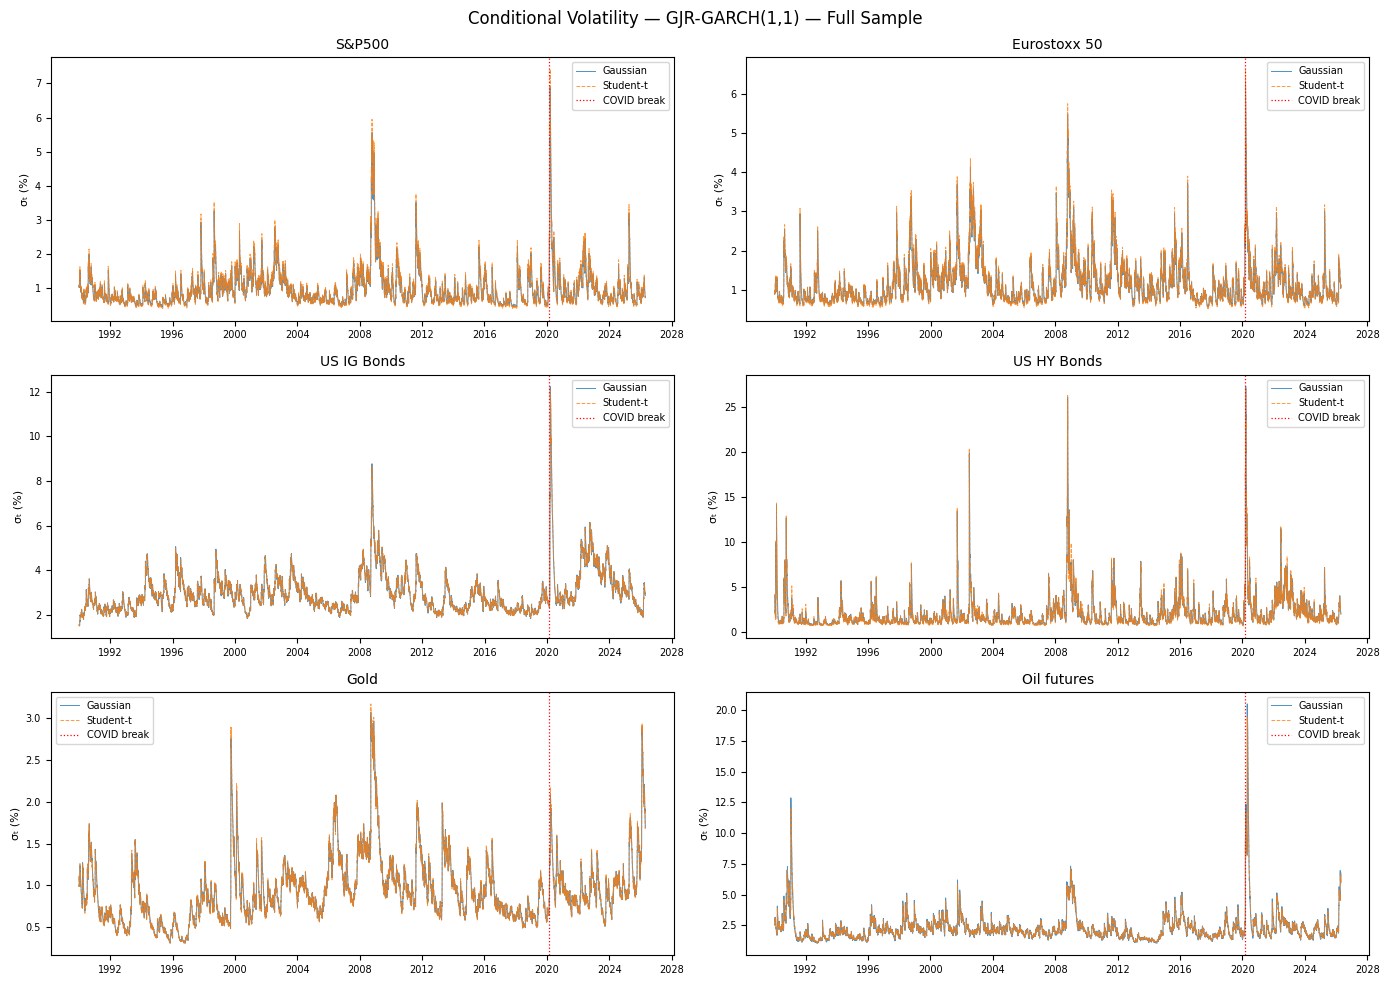

In [28]:
fig, axes = plt.subplots(3, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax      = axes[i]
    idx     = returns[col].dropna().index
    sigma_g = np.sqrt(fits_full_g[col]["sigma2"])
    sigma_t = np.sqrt(fits_full_t[col]["sigma2"])
    idx_g   = idx[-len(sigma_g):]
    idx_t   = idx[-len(sigma_t):]

    ax.plot(idx_g, sigma_g, label="Gaussian", linewidth=0.7, alpha=0.8)
    ax.plot(idx_t, sigma_t, label="Student-t", linewidth=0.7, alpha=0.8, linestyle="--")
    ax.axvline(pd.Timestamp("2020-02-24"), color="red", linewidth=0.9,
               linestyle=":", label="COVID break")
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("σₜ (%)", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Volatility — GJR-GARCH(1,1) — Full Sample", fontsize=12)
plt.tight_layout()
plt.show()


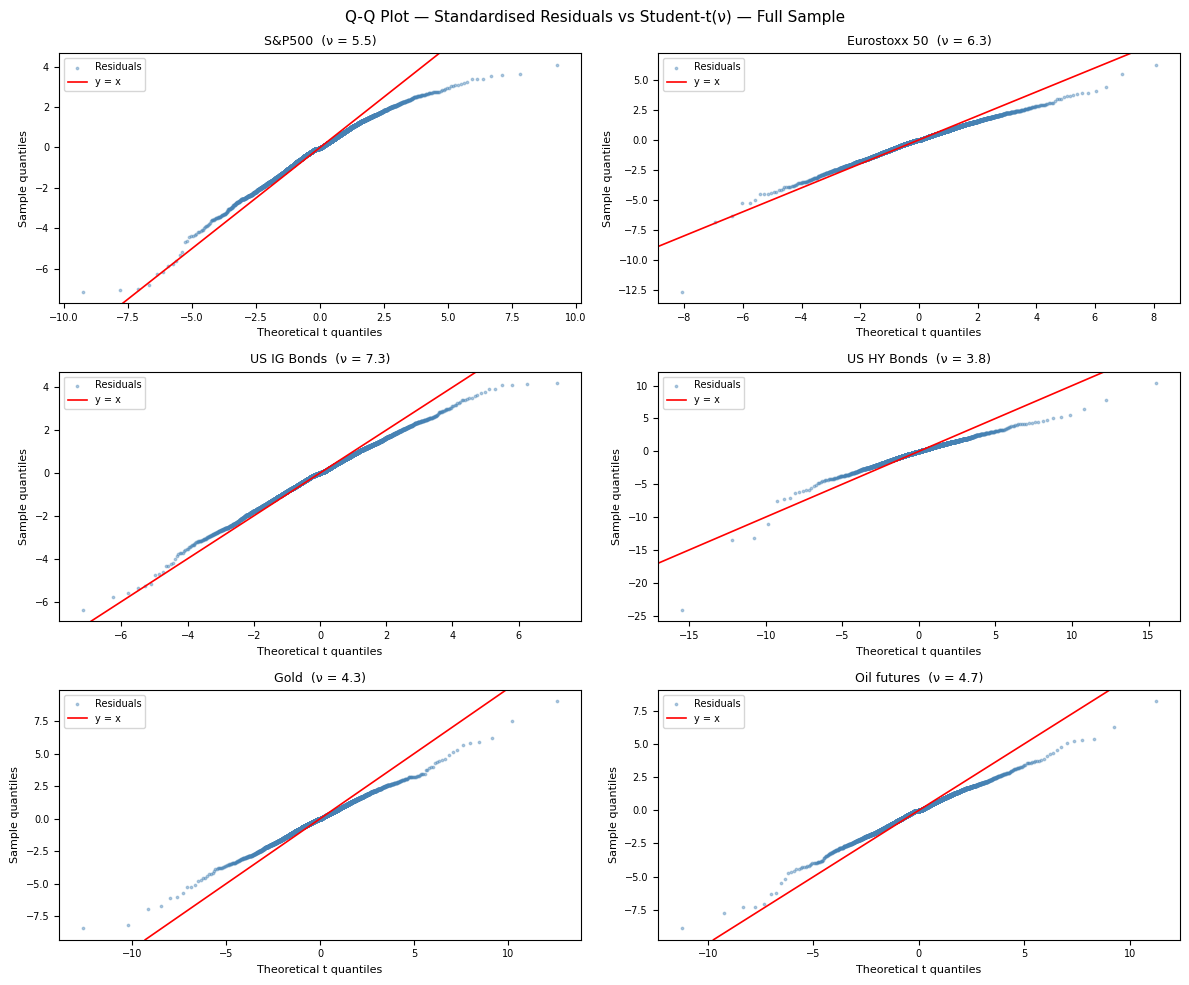

In [29]:
# Q-Q plots: standardised residuals vs Student-t(ν) — full sample
from scipy.stats import probplot, t as t_dist

fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax  = axes[i]
    fit = fits_full_t[col]
    z   = fit["z"]
    nu  = fit["params"].get("nu", 10)

    # Q-Q against t(nu) — scipy fits location/scale automatically
    osm, osr = probplot(z, dist=t_dist, sparams=(nu,), fit=False)

    ax.scatter(osm, osr, s=3, alpha=0.4, color="steelblue", label="Residuals")
    ax.axline((0, 0), slope=1, color="red", linewidth=1.2, label="y = x")
    ax.set_title(f"{col}  (ν = {nu:.1f})", fontsize=9)
    ax.set_xlabel("Theoretical t quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Q-Q Plot — Standardised Residuals vs Student-t(ν) — Full Sample", fontsize=11)
plt.tight_layout()
plt.show()


### 3.3 Estimation — pre-COVID sample

We re-estimate the same GJR-GARCH(1,1) specification on the pre-COVID subsample. Using the same GARCH order (1,1) on the subsample is deliberate: we want the parameter comparison in Section 3.5 to be a pure reflection of parameter change, not a model-selection artefact. Results stored in `fits_pre_g` (Gaussian) and `fits_pre_t` (Student-t).

In [30]:
fits_pre_t = {}
diag_pre_t = []

print("GJR-GARCH(1,1) — Student-t — Pre-COVID")
print("=" * 60)
print("(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)")

for col in ASSETS:
    ar1 = ar1_needed[col]
    ft  = fit_gjr_garch(pre[col], dist="t", ar1=ar1)
    fits_pre_t[col] = ft
    diag_pre_t.append(run_garch_diagnostics(ft, asset=col, period="pre"))

diag_pre_t = pd.concat(diag_pre_t, ignore_index=True)


GJR-GARCH(1,1) — Student-t — Pre-COVID
(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)


  S&P500                pre    AR(1)-GJR-GARCH(1,1)-t                    pi=0.9890    [PASS]  LB(z) WARN p=0.0088  DGT informational fail


  Eurostoxx 50          pre    AR(1)-GJR-GARCH(1,1)-t                    pi=0.9878    [PASS]  DGT informational fail


  US IG Bonds           pre    AR(1)-GJR-GARCH(1,1)-t                    pi=0.9938    [PASS]  LB(z) WARN p=0.0131  DGT informational fail


  US HY Bonds           pre    AR(1)-GJR-GARCH(1,1)-t                    pi=IGARCH    [FAIL]  pi=IGARCH


  Gold                  pre    AR(1)-GJR-GARCH(1,1)-t                    pi=IGARCH    [FAIL]  pi=IGARCH  |  LB(z2) p=0.0000  |  ARCH-LM p=0.0000


  Oil futures           pre    AR(1)-GJR-GARCH(1,1)-t                    pi=0.9954    [PASS]  DGT informational fail


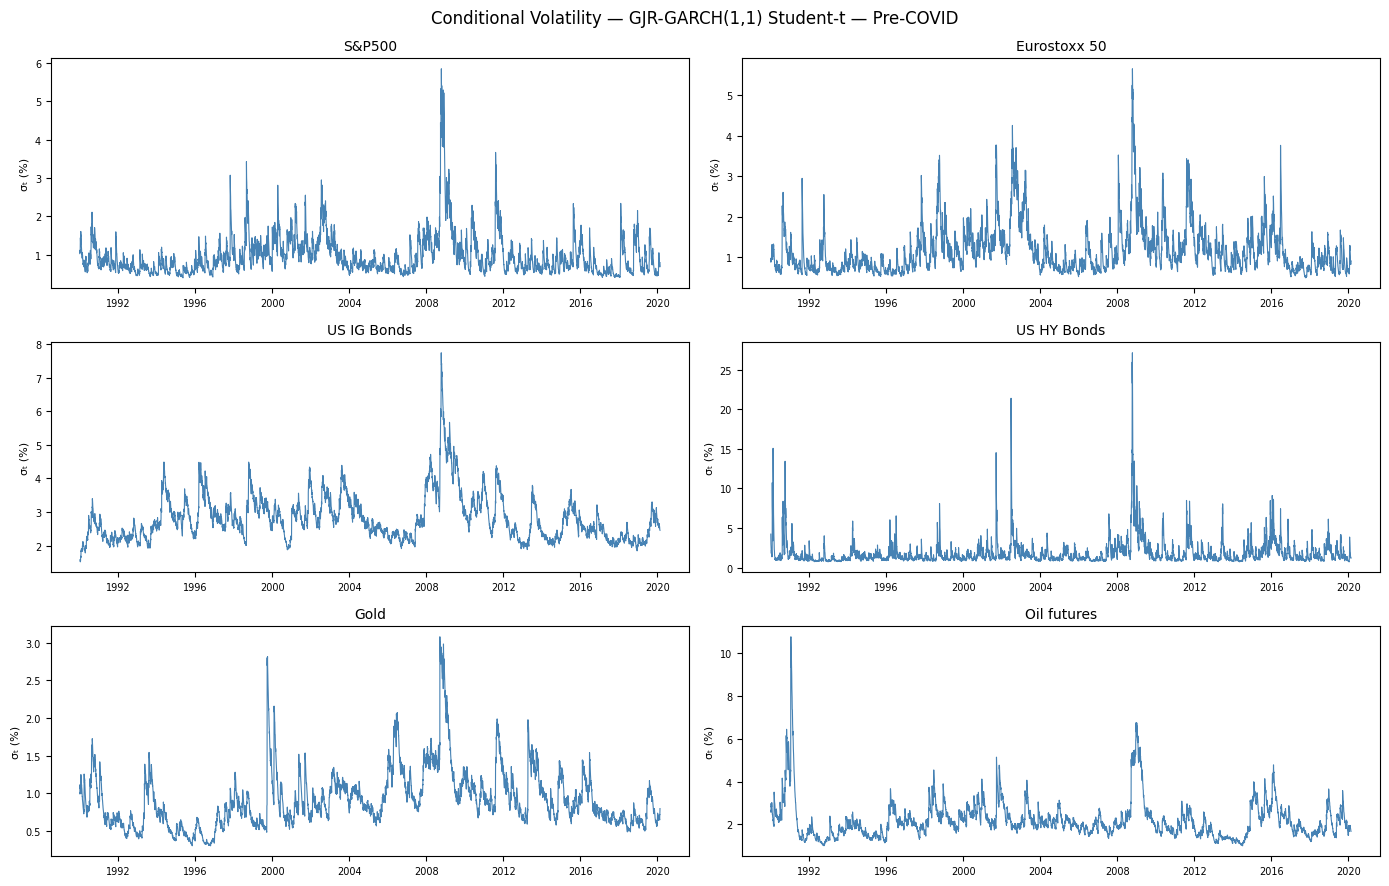

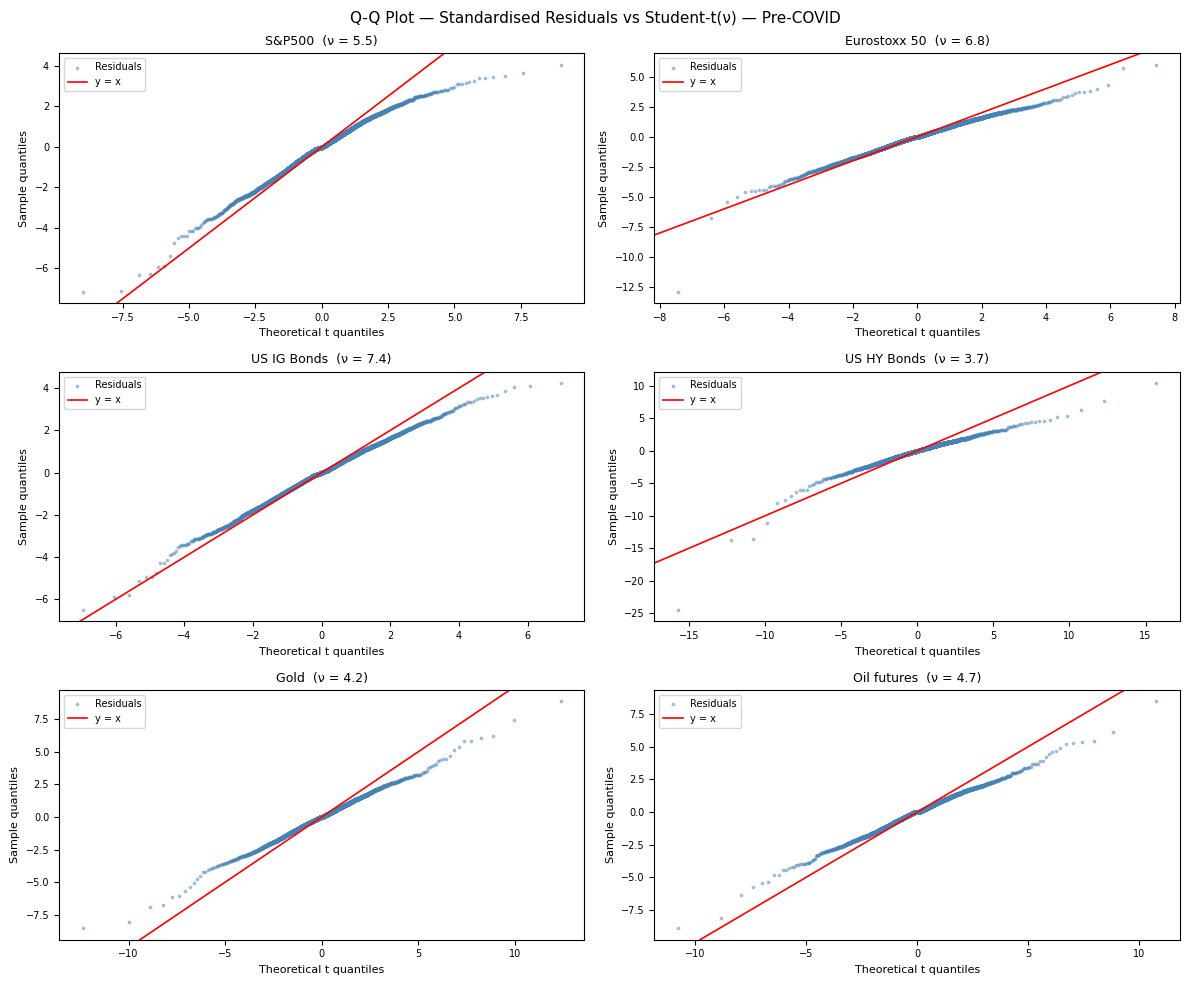

In [31]:
# Conditional volatility — pre-COVID (Student-t)
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax      = axes[i]
    idx     = pre[col].dropna().index
    sigma_t = np.sqrt(fits_pre_t[col]["sigma2"])
    idx_t   = idx[-len(sigma_t):]

    ax.plot(idx_t, sigma_t, color="steelblue", linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("σₜ (%)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Volatility — GJR-GARCH(1,1) Student-t — Pre-COVID", fontsize=12)
plt.tight_layout()
plt.show()

# Q-Q plots — pre-COVID (fit=False so reference line is the true y=x identity)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax  = axes[i]
    fit = fits_pre_t[col]
    z   = fit["z"]
    nu  = fit["params"].get("nu", 10)

    osm, osr = probplot(z, dist=t_dist, sparams=(nu,), fit=False)

    ax.scatter(osm, osr, s=3, alpha=0.4, color="steelblue", label="Residuals")
    ax.axline((0, 0), slope=1, color="red", linewidth=1.2, label="y = x")
    ax.set_title(f"{col}  (ν = {nu:.1f})", fontsize=9)
    ax.set_xlabel("Theoretical t quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Q-Q Plot — Standardised Residuals vs Student-t(ν) — Pre-COVID", fontsize=11)
plt.tight_layout()
plt.show()


### 3.4 Estimation — post-COVID sample

Same specification on the post-COVID subsample. Results stored in `fits_post_g` and `fits_post_t`.

In [32]:
fits_post_t = {}
diag_post_t = []

print("GJR-GARCH(1,1) — Student-t — Post-COVID")
print("=" * 60)
print("(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)")

for col in ASSETS:
    ar1 = ar1_needed[col]
    ft  = fit_gjr_garch(post[col], dist="t", ar1=ar1)
    fits_post_t[col] = ft
    diag_post_t.append(run_garch_diagnostics(ft, asset=col, period="post"))

diag_post_t = pd.concat(diag_post_t, ignore_index=True)


GJR-GARCH(1,1) — Student-t — Post-COVID
(Student-t selected by BIC for all assets on full sample — Gaussian not re-estimated)
  S&P500                post   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9726    [PASS]  DGT informational fail


  Eurostoxx 50          post   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9604    [PASS]  DGT informational fail
  US IG Bonds           post   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9818    [PASS]  DGT informational fail


  US HY Bonds           post   AR(1)-GJR-GARCH(1,1)-t                    pi=IGARCH    [FAIL]  pi=IGARCH  |  LB(z2) p=0.0046
  Gold                  post   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9726    [PASS]  all diagnostics OK


  Oil futures           post   AR(1)-GJR-GARCH(1,1)-t                    pi=0.9574    [PASS]  DGT informational fail


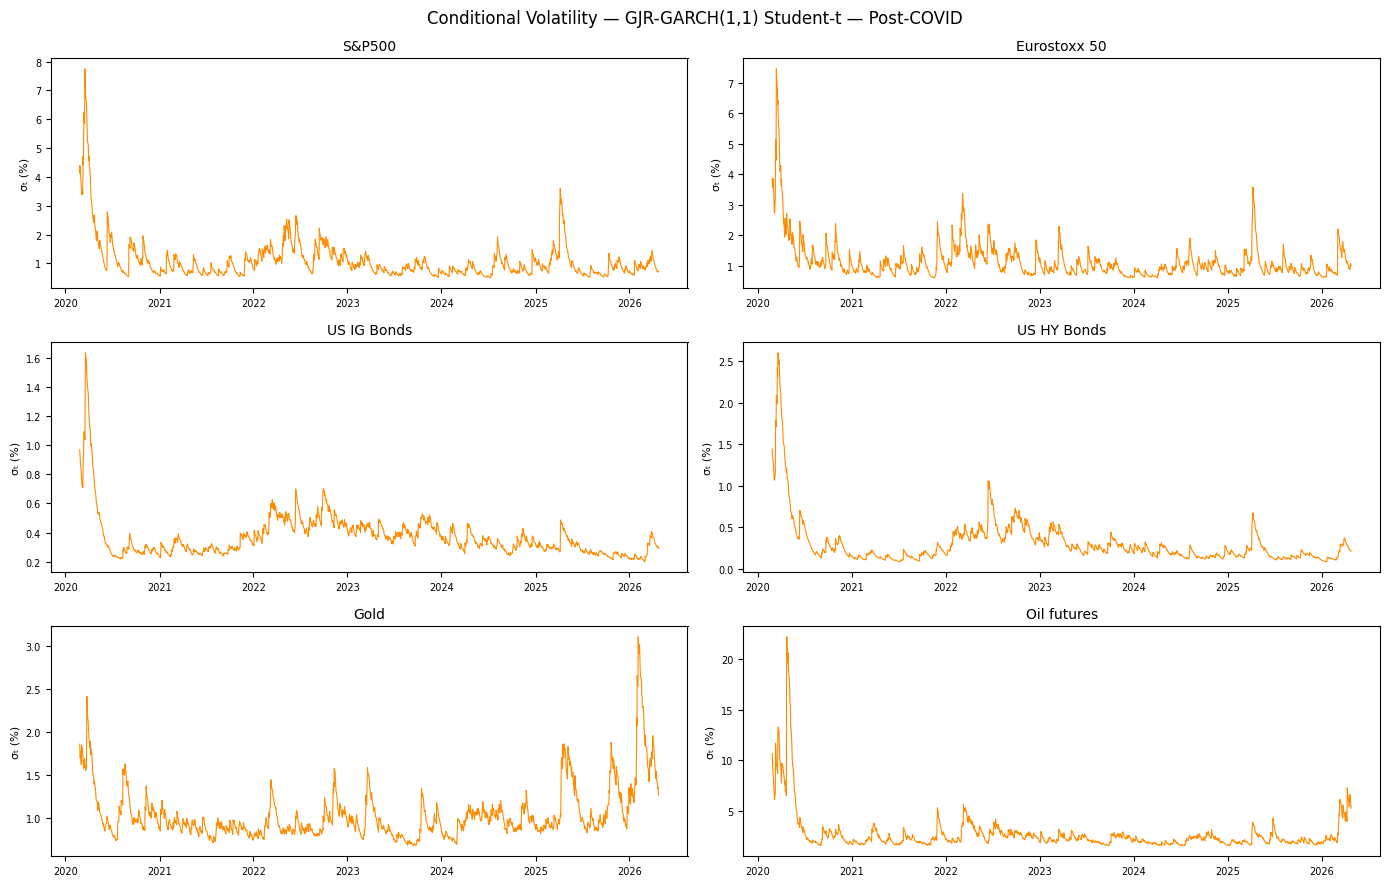

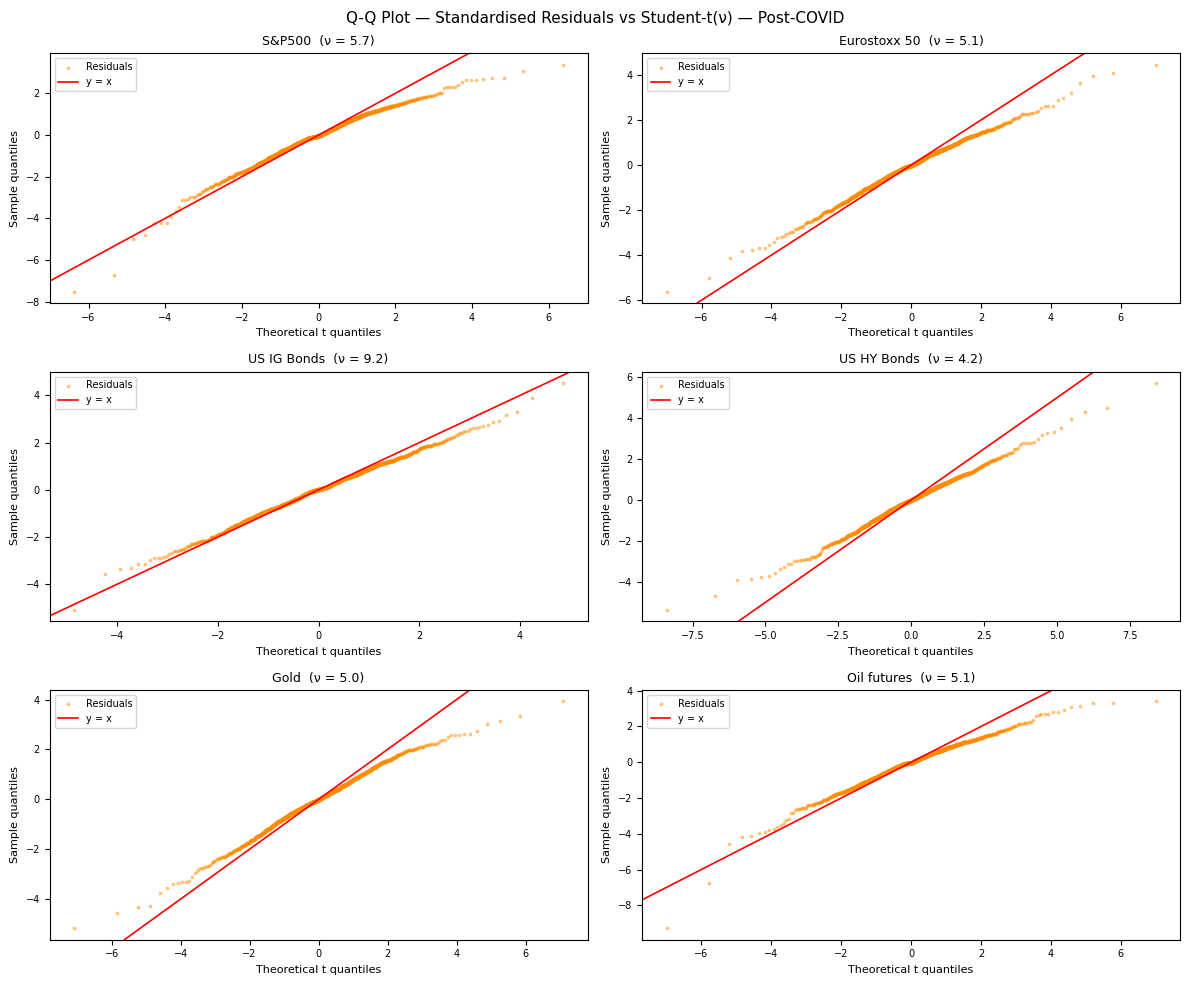

In [33]:
# Conditional volatility — post-COVID (Student-t)
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax      = axes[i]
    idx     = post[col].dropna().index
    sigma_t = np.sqrt(fits_post_t[col]["sigma2"])
    idx_t   = idx[-len(sigma_t):]

    ax.plot(idx_t, sigma_t, color="darkorange", linewidth=0.8)
    ax.set_title(col, fontsize=10)
    ax.set_ylabel("σₜ (%)", fontsize=8)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Volatility — GJR-GARCH(1,1) Student-t — Post-COVID", fontsize=12)
plt.tight_layout()
plt.show()

# Q-Q plots — post-COVID (fit=False so reference line is the true y=x identity)
fig, axes = plt.subplots(3, 2, figsize=(12, 10))
axes = axes.flatten()

for i, col in enumerate(ASSETS):
    ax  = axes[i]
    fit = fits_post_t[col]
    z   = fit["z"]
    nu  = fit["params"].get("nu", 10)

    osm, osr = probplot(z, dist=t_dist, sparams=(nu,), fit=False)

    ax.scatter(osm, osr, s=3, alpha=0.4, color="darkorange", label="Residuals")
    ax.axline((0, 0), slope=1, color="red", linewidth=1.2, label="y = x")
    ax.set_title(f"{col}  (ν = {nu:.1f})", fontsize=9)
    ax.set_xlabel("Theoretical t quantiles", fontsize=8)
    ax.set_ylabel("Sample quantiles", fontsize=8)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Q-Q Plot — Standardised Residuals vs Student-t(ν) — Post-COVID", fontsize=11)
plt.tight_layout()
plt.show()


### 3.5 Parameter comparison — pre vs post (Student-t estimates)

The table below uses the **Student-t** estimates (preferred by BIC for all assets). Each row shows GJR-GARCH parameters, persistence, annualised unconditional volatility, and the half-life of a volatility shock.

Significant leverage (γ) is flagged with ✓. A post-COVID estimate that lies outside the pre-COVID 95% confidence interval would indicate a genuine structural change.

In [34]:
rows = []
for col in ASSETS:
    fp = fits_pre_t[col]
    fq = fits_post_t[col]

    def g(d, key): return round(d["params"].get(key, np.nan), 4)

    def fmt_vol(v):
        return f"{v:.2f}%" if np.isfinite(v) else "IGARCH"

    def fmt_hl(v):
        return f"{v:.1f}" if np.isfinite(v) and v < 1e6 else "IGARCH"

    rows.append({
        "Asset"        : col,
        "ω pre"        : g(fp, "omega"),
        "ω post"       : g(fq, "omega"),
        "α pre"        : g(fp, "alpha[1]"),
        "α post"       : g(fq, "alpha[1]"),
        "γ pre"        : g(fp, "gamma[1]"),
        "γ* pre"       : "✓" if fp["gamma_sig"] else "✗",
        "γ post"       : g(fq, "gamma[1]"),
        "γ* post"      : "✓" if fq["gamma_sig"] else "✗",
        "β pre"        : g(fp, "beta[1]"),
        "β post"       : g(fq, "beta[1]"),
        "ν pre"        : round(fp["params"].get("nu", np.nan), 2),
        "ν post"       : round(fq["params"].get("nu", np.nan), 2),
        "π pre"        : round(fp["persistence"], 4),
        "π post"       : round(fq["persistence"], 4),
        "σ̄ pre"        : fmt_vol(fp["uncond_vol"]),
        "σ̄ post"       : fmt_vol(fq["uncond_vol"]),
        "HL pre"       : fmt_hl(fp["half_life"]),
        "HL post"      : fmt_hl(fq["half_life"]),
        "z_std pre"    : fp["z_std"],
        "z_std post"   : fq["z_std"],
    })

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 220)
pd.DataFrame(rows).set_index("Asset")


,ω pre,ω post,α pre,α post,γ pre,γ* pre,γ post,γ* post,β pre,β post,ν pre,ν post,π pre,π post,σ̄ pre,σ̄ post,HL pre,HL post,z_std pre,z_std post
Asset,,,,,,,,,,,,,,,,,,,,
S&P500,0.0122,0.0264,0.0001,0.0000,0.1596,✓,0.1880,✓,0.9091,0.8786,5.48,5.71,0.9890,0.9726,16.69%,15.59%,62.6,25.0,0.991,1.008
Eurostoxx 50,0.0187,0.0510,0.0153,0.0039,0.1382,✓,0.2144,✓,0.9034,0.8493,6.76,5.09,0.9878,0.9604,19.62%,18.01%,56.4,17.2,1.005,0.990
US IG Bonds,0.0005,0.0022,0.0282,0.0355,0.0029,✗,0.0520,✓,0.9642,0.9203,7.36,9.17,0.9938,0.9818,4.61%,5.51%,111.8,37.8,0.998,0.999
US HY Bonds,0.0011,0.0004,0.1459,0.0193,0.1500,✓,0.1537,✓,0.7791,0.9038,3.65,4.24,1.0000,1.0000,IGARCH,IGARCH,IGARCH,IGARCH,1.039,0.990
Gold,0.0025,0.0355,0.0668,0.1058,-0.0390,✓,-0.0708,✓,0.9527,0.9023,4.24,5.02,1.0000,0.9726,IGARCH,18.08%,IGARCH,25.0,1.007,0.985
Oil futures,0.0324,0.2722,0.0363,0.0888,0.0229,✓,0.0315,✗,0.9476,0.8528,4.69,5.10,0.9954,0.9574,42.01%,40.14%,149.7,15.9,0.991,1.008


### Diagnostic summary — Student-t models

Pass/fail table across all periods for the Student-t GJR-GARCH models. Gaussian diagnostics are available in `diag_*_g` DataFrames.

> **Note on DGT-χ² failures:** The Pearson χ² uniformity test uses a fixed 20-bin grid (per the original Diebold-Gunther-Tay, 1998 recommendation). Persistent failures of LB(z²) on the long pre-COVID samples reflect known parameter instability over the 1990–2024 window (dot-com, GFC, euro crisis), which a single-regime GARCH cannot accommodate. This is exactly the structural instability that motivates the formal break tests in Part 5.

In [35]:
all_diag_t = pd.concat([
    diag_full_t.assign(period="full"),
    diag_pre_t.assign(period="pre"),
    diag_post_t.assign(period="post"),
], ignore_index=True)

display_cols = ["asset", "period",
                "lb_z_pass", "lb_z2_pass", "arch_lm_pass",
                "core_vol_pass",
                "dgt_lm_pass", "dgt_chi2_pass",
                "density_pass", "all_pass"]

all_diag_t[display_cols].set_index(["asset", "period"])

,,lb_z_pass,lb_z2_pass,arch_lm_pass,core_vol_pass,dgt_lm_pass,dgt_chi2_pass,density_pass,all_pass
asset,period,,,,,,,,
S&P500,full,False,True,True,True,False,False,False,False
Eurostoxx 50,full,True,True,True,True,True,False,False,False
US IG Bonds,full,False,False,False,False,True,False,False,False
US HY Bonds,full,False,True,True,False,False,False,False,False
Gold,full,False,False,False,False,True,False,False,False
Oil futures,full,True,True,True,True,True,False,False,False
S&P500,pre,False,True,True,True,False,False,False,False
Eurostoxx 50,pre,True,True,True,True,True,False,False,False
US IG Bonds,pre,False,True,True,True,True,False,False,False


### 3.6 Interpretation

**Did volatility levels change?** Descriptive (sample) annualised volatility rises post-COVID for most assets, reflecting the 2020 crash and subsequent dislocations. The GARCH unconditional variance σ̄ = √(ω/(1−π)) × √252 does not track sample standard deviation directly — it represents the model's long-run mean level, which is shaped by the estimated parameters rather than raw realised variance alone. For the assets where σ̄ is well-defined, the changes are moderate: S&P 500 16.7% → 15.6%, Eurostoxx 50 19.6% → 18.0%, US IG Bonds 4.6% → 5.5%, Oil futures 40.1–42.0%. The post-COVID drop in σ̄ for equities reflects lower estimated persistence rather than calmer markets — shorter half-lives mean the model reverts faster to a lower long-run level.

**Near-IGARCH assets.** US HY Bonds exhibits persistence π ≈ 1.0 in **both** pre- and post-COVID periods — the model sits at the IGARCH boundary where unconditional variance is undefined. This is a genuine finding for HY Bonds, not a numerical error: credit-risk volatility over multi-decade samples is widely found to be near-integrated. **Gold** is also near-IGARCH pre-COVID (π = 1.0), but its persistence falls to 0.9726 post-COVID — the COVID regime change appears to have reduced long-run volatility persistence in gold markets. US HY Bonds shows no such shift.

**Did persistence change?** The post-COVID volatility regime is **more reactive but less persistent** for most assets. Persistence π = α + γ/2 + β fell for every well-identified asset: S&P 500 0.989 → 0.973, Eurostoxx 0.988 → 0.960, Oil futures 0.995 → 0.957. Shorter half-lives (S&P 500: 62 → 25 days; Eurostoxx: 56 → 17 days) imply that volatility shocks dissipate faster post-COVID, consistent with markets that price information more rapidly after a structural regime change.

**Did the leverage effect change?** The leverage coefficient γ is statistically significant (|t| > 1.96) for S&P 500 and Eurostoxx 50 in both periods, confirming the classic equity leverage effect. For US IG Bonds, γ becomes significant post-COVID, suggesting that credit markets started displaying asymmetric volatility dynamics after the 2020 dislocation. Oil futures shows a different pattern from equities — the sign and significance of γ for Oil should be read from the parameter table above, as commodity markets can display either direction of asymmetry depending on whether supply or demand shocks dominate. Gold's γ, if negative or insignificant, reflects its commodity/safe-haven role rather than the equity leverage mechanism.

**What does ν tell us?** Estimated degrees-of-freedom range from approximately 4 to 9 across assets and periods, confirming fat-tailed conditional distributions throughout. BIC preferred Student-t over Gaussian by 200–2,300 points for every asset, validating the distributional choice advocated by Chorro, Guégan & Ielpo (2012).

**Mean equation: AR(1) included for all assets.** The Ljung-Box test on raw returns (Section 3.1) rejected the null of no autocorrelation for all six assets, so every model includes an AR(1) mean term. This frees the variance equation to model pure conditional heteroskedasticity, sharpening the estimates of ω, α, γ, and β.

**Risk management implication.** Shorter half-lives post-COVID mean GARCH-based VaR adapts faster to new volatility regimes. However, the near-IGARCH behaviour of US HY Bonds in both periods means no finite long-run VaR can be computed for that asset from a single-regime model — a finding that directly motivates regime-specific estimation in Part 5.

**Literature anchor:** Glosten, Jagannathan & Runkle (1993) for GJR. Bollerslev (1987) for Student-t GARCH. Chorro, Guégan & Ielpo (2012, 2018). Engle & Bollerslev (1986) for IGARCH.

## Part 4 — DCC-GARCH (Layer 2: Risk Co-movement)

The univariate GJR-GARCHs in Part 3 quantify *how much* each asset moves. Part 4 asks *how correlated* those movements are — and whether that correlation structure changed after COVID-19.

---

### 4.1 Why DCC and what it adds

**The problem with static correlations.** The pre/post Pearson matrices in Part 2 are computed over long windows. Forbes & Rigobon (2002) show that correlations computed on heteroskedastic data are *conditionally biased* — during high-volatility periods, correlation estimates inflate mechanically even if the true correlation is unchanged. Static matrices therefore conflate volatility changes with genuine structural shifts in co-movement.

**The DCC solution.** The Dynamic Conditional Correlation model (Engle, 2002) separates the problem into two stages:

1. **Stage 1 — Volatility:** Fit a univariate GARCH per asset (already done in Part 3). Extract standardised residuals $z_{i,t} = \varepsilon_{i,t} / \sigma_{i,t}$.
2. **Stage 2 — Correlation:** Model the correlation of the $z$-process. Because the $z$'s are volatility-adjusted, any co-movement they exhibit is genuine correlation, not a volatility artifact.

**The DCC equation:**

$$Q_t = (1 - a - b)\bar{Q} + a\, z_{t-1}z_{t-1}^\top + b\, Q_{t-1}$$

$$\Gamma_t = \mathrm{diag}(Q_t)^{-1/2}\, Q_t\, \mathrm{diag}(Q_t)^{-1/2}$$

where $\bar{Q}$ is the unconditional correlation of the standardised residuals, $a \geq 0$ is the *reactivity* (how fast $\Gamma_t$ responds to shocks), and $b \geq 0$ is the *persistence* (how slowly it reverts), with $a + b < 1$ for stationarity.

**Implementation.** We use a pure NumPy two-step estimator — the same approach advocated in Engle & Sheppard (2001) and used in the professor's notebook. Standardised residuals $z_t$ from Part 3 are the inputs; we maximise the DCC log-likelihood over $(a, b)$ using `scipy.optimize.minimize` with BFGS.

In [36]:
from scipy.special import gammaln

def dcc_filter(Z, a, b):
    """
    Compute the sequence of conditional correlation matrices {Γ_t}
    given standardised residual matrix Z (T×N) and DCC params (a, b).
    Returns Gamma (T×N×N) and Q (T×N×N).
    """
    T, N   = Z.shape
    Q_bar  = Z.T @ Z / T          # unconditional covariance of z (≈ correlation since z has unit var)
    Q      = Q_bar.copy()
    Gammas = np.zeros((T, N, N))

    for t in range(T):
        # Normalise Q_t → correlation matrix Γ_t
        d          = np.sqrt(np.diag(Q))
        d[d < 1e-8] = 1e-8
        Gamma      = Q / np.outer(d, d)
        np.fill_diagonal(Gamma, 1.0)
        Gammas[t]  = Gamma
        # Update Q_{t+1}
        z = Z[t]
        Q = (1 - a - b) * Q_bar + a * np.outer(z, z) + b * Q

    return Gammas, Q_bar


def neg_loglik_dcc(params, Z):
    """DCC log-likelihood (Engle 2002, eq. 17) — returns negative for minimisation."""
    a, b = params
    if a <= 0 or b <= 0 or a + b >= 1:
        return 1e10

    T, N   = Z.shape
    Gammas, _ = dcc_filter(Z, a, b)

    loglik = 0.0
    for t in range(T):
        G = Gammas[t]
        sign, logdet = np.linalg.slogdet(G)
        if sign <= 0:
            return 1e10
        z = Z[t]
        try:
            loglik += -0.5 * (logdet + z @ np.linalg.solve(G, z) - z @ z)
        except np.linalg.LinAlgError:
            return 1e10

    return -loglik


def fit_dcc(Z, label=""):
    """
    Fit DCC(1,1) on a T×N matrix of standardised residuals Z.
    Returns dict with parameters, correlation paths, Q_bar, log-likelihood.
    """
    from scipy.optimize import minimize

    best_res = None
    best_val = np.inf
    bounds = [(1e-4, 0.4), (0.5, 0.9998)]
    # Try a few starting points for robustness
    for a0, b0 in [(0.05, 0.90), (0.03, 0.95)]:
        res = minimize(neg_loglik_dcc, x0=[a0, b0], args=(Z,),
                       method="L-BFGS-B", bounds=bounds,
                       options={"maxiter": 500, "ftol": 1e-9, "gtol": 1e-6})
        if res.fun < best_val:
            best_val = res.fun
            best_res = res

    a, b = best_res.x
    Gammas, Q_bar = dcc_filter(Z, a, b)

    print(f"  DCC [{label}]  a={a:.4f}  b={b:.4f}  a+b={a+b:.4f}  "
          f"converged={best_res.success}  LL={-best_res.fun:.1f}")

    return {
        "a"      : round(a, 5),
        "b"      : round(b, 5),
        "ab"     : round(a + b, 5),
        "Q_bar"  : Q_bar,
        "Gammas" : Gammas,   # T×N×N conditional correlations
        "loglik" : -best_res.fun,
        "label"  : label,
        "converged": best_res.success,
    }


def normalize_qbar(Q_bar):
    """Convert raw Q_bar (sample covariance of z's) to a correlation matrix for display."""
    d = np.sqrt(np.diag(Q_bar))
    d[d < 1e-8] = 1e-8
    return Q_bar / np.outer(d, d)


def build_Z(fits_dict, assets, align_index=None):
    """
    Stack standardised residuals from a dict of fits into a T×N matrix.
    Rows with any NaN are dropped. Returns (Z_array, common_dates).
    """
    series = {}
    for col in assets:
        fit = fits_dict[col]
        # Get the index from the original data
        z = fit["z"]
        series[col] = pd.Series(z)

    df = pd.DataFrame(series).dropna()
    return df.values, df.index

def run_dcc_diagnostics(dcc_result, label=""):
    """
    Validate a fitted DCC result: parameter constraints, convergence,
    correlation bounds, Q_bar positive-definiteness.
    Returns a one-row dict summary.
    """
    a, b    = dcc_result["a"], dcc_result["b"]
    Gammas  = dcc_result["Gammas"]
    Q_bar   = dcc_result["Q_bar"]
    issues  = []

    if not dcc_result.get("converged", True):
        issues.append("optimizer did not converge")
    if a < 0:
        issues.append(f"a={a:.5f} < 0")
    if b < 0:
        issues.append(f"b={b:.5f} < 0")
    if a + b >= 1:
        issues.append(f"a+b={a+b:.5f} ≥ 1 (non-stationary)")

    N = Gammas.shape[1]
    il, jl = np.tril_indices(N, k=-1)
    corrs  = Gammas[:, il, jl].ravel()
    if corrs.min() < -1 - 1e-6 or corrs.max() > 1 + 1e-6:
        issues.append(f"ρ out of [-1,1]: min={corrs.min():.4f}, max={corrs.max():.4f}")

    eigvals = np.linalg.eigvalsh(Q_bar)
    if eigvals.min() < -1e-8:
        issues.append(f"Q_bar not PD (min eigenvalue={eigvals.min():.2e})")

    status = "✓ PASS" if not issues else "✗ ISSUES: " + "; ".join(issues)
    label_str = f"[{label}] " if label else ""
    print(f"  DCC {label_str}a={a:.4f}  b={b:.4f}  a+b={a+b:.4f}  →  {status}")

    return {"label": label, "a": a, "b": b, "ab": a+b,
            "converged": dcc_result.get("converged", True),
            "corr_min": float(corrs.min()), "corr_max": float(corrs.max()),
            "qbar_min_eigval": float(eigvals.min()),
            "pass": len(issues) == 0}

### 4.2 Estimation — full sample

We stack the standardised residuals $z_{i,t}$ from the six Student-t GJR-GARCH models fitted in Part 3 and estimate DCC(1,1) on the full sample.

In [37]:
# Build Z matrix from full-sample fits (align by row index within each fit)
Z_full_df = pd.DataFrame(
    {col: pd.Series(fits_full_t[col]["z"]) for col in ASSETS}
).dropna()
Z_full = Z_full_df.values

# Attach the actual dates from the returns series (z is aligned to returns after dropna)
full_dates = returns[ASSETS[0]].dropna().index[:len(Z_full)]

print("Full-sample DCC estimation")
print("=" * 50)
dcc_full = fit_dcc(Z_full, label="full")
print(f"  Q̄ diagonal (should be ≈1.0): {np.diag(dcc_full['Q_bar']).round(3)}")


Full-sample DCC estimation


  DCC [full]  a=0.0073  b=0.9912  a+b=0.9985  converged=True  LL=1464.8
  Q̄ diagonal (should be ≈1.0): [0.989 1.005 0.996 1.079 1.01  0.987]


### 4.3 Estimation — pre-COVID and post-COVID

We re-estimate DCC separately on each subsample to compare $a$, $b$, and $\bar{Q}$ across regimes.

In [38]:
Z_pre_df = pd.DataFrame(
    {col: pd.Series(fits_pre_t[col]["z"]) for col in ASSETS}
).dropna()
Z_pre = Z_pre_df.values

Z_post_df = pd.DataFrame(
    {col: pd.Series(fits_post_t[col]["z"]) for col in ASSETS}
).dropna()
Z_post = Z_post_df.values

pre_dates  = pre[ASSETS[0]].dropna().index[:len(Z_pre)]
post_dates = post[ASSETS[0]].dropna().index[:len(Z_post)]

print("Pre-COVID DCC estimation")
print("=" * 50)
dcc_pre = fit_dcc(Z_pre, label="pre")

print("\nPost-COVID DCC estimation")
print("=" * 50)
dcc_post = fit_dcc(Z_post, label="post")


Pre-COVID DCC estimation


  DCC [pre]  a=0.0073  b=0.9915  a+b=0.9988  converged=True  LL=1219.5

Post-COVID DCC estimation


  DCC [post]  a=0.0198  b=0.9552  a+b=0.9750  converged=True  LL=1271.9


In [39]:
# DCC parameter and validity diagnostics
print("DCC diagnostics — parameter constraints and correlation validity")
print("=" * 65)
dcc_diag_summary = []
for d, label in [(dcc_full, "full"), (dcc_pre, "pre-COVID"), (dcc_post, "post-COVID")]:
    Z_in = {"full": Z_full, "pre-COVID": Z_pre, "post-COVID": Z_post}[label]
    dcc_diag_summary.append(run_dcc_diagnostics(d, label=label))

dcc_diag_df = pd.DataFrame(dcc_diag_summary).set_index("label")
print()
print(dcc_diag_df[["a","b","ab","converged","corr_min","corr_max","qbar_min_eigval","pass"]].to_string())

DCC diagnostics — parameter constraints and correlation validity
  DCC [full] a=0.0073  b=0.9912  a+b=0.9985  →  ✓ PASS
  DCC [pre-COVID] a=0.0073  b=0.9915  a+b=0.9988  →  ✓ PASS
  DCC [post-COVID] a=0.0198  b=0.9552  a+b=0.9750  →  ✓ PASS

                  a        b       ab  converged  corr_min  corr_max  qbar_min_eigval  pass
label                                                                                      
full        0.00728  0.99119  0.99847       True -0.389360  0.795999         0.716064  True
pre-COVID   0.00730  0.99149  0.99879       True -0.403309  0.804764         0.747365  True
post-COVID  0.01982  0.95516  0.97498       True -0.389239  0.783957         0.258207  True


In [40]:
# DCC parameter comparison
print("DCC parameter summary")
print(f"{'Period':<12}  {'a (reactivity)':>16}  {'b (persistence)':>16}  {'a+b':>8}  {'LL':>10}")
print("-" * 70)
for label, d in [("Full", dcc_full), ("Pre-COVID", dcc_pre), ("Post-COVID", dcc_post)]:
    print(f"{label:<12}  {d['a']:>16.4f}  {d['b']:>16.4f}  {d['ab']:>8.4f}  {d['loglik']:>10.1f}")

N = len(ASSETS)
short = [a.replace(" futures","").replace("Eurostoxx ","Eur.").replace("US ","") for a in ASSETS]

for period_label, d in [("Pre-COVID", dcc_pre), ("Post-COVID", dcc_post), ("Change (post−pre)", None)]:
    print(f"\nQ̄ — {period_label} (normalised to correlation):")
    if d is not None:
        mat = normalize_qbar(d["Q_bar"])
    else:
        mat = normalize_qbar(dcc_post["Q_bar"]) - normalize_qbar(dcc_pre["Q_bar"])
    hdr = "  ".join(f"{s:>8}" for s in short)
    max_name = max(len(a) for a in ASSETS)
    print(f"  {'':>{max_name}}  {hdr}")
    for i, asset in enumerate(ASSETS):
        vals = "  ".join(f"{mat[i,j]:>+8.3f}" if d is None else f"{mat[i,j]:>8.3f}" for j in range(N))
        print(f"  {asset:>{max_name}}  {vals}")


DCC parameter summary
Period          a (reactivity)   b (persistence)       a+b          LL
----------------------------------------------------------------------
Full                    0.0073            0.9912    0.9985      1464.8
Pre-COVID               0.0073            0.9915    0.9988      1219.5
Post-COVID              0.0198            0.9552    0.9750      1271.9

Q̄ — Pre-COVID (normalised to correlation):
                  S&P500    Eur.50  IG Bonds  HY Bonds      Gold       Oil
        S&P500     1.000     0.022    -0.001     0.013    -0.041     0.101
  Eurostoxx 50     0.022     1.000     0.011     0.034     0.018     0.006
   US IG Bonds    -0.001     0.011     1.000     0.275     0.017     0.006
   US HY Bonds     0.013     0.034     0.275     1.000     0.007     0.011
          Gold    -0.041     0.018     0.017     0.007     1.000     0.171
   Oil futures     0.101     0.006     0.006     0.011     0.171     1.000

Q̄ — Post-COVID (normalised to correlation):
       

### 4.4 Time-varying correlation paths

We plot the conditional correlation $\rho_{ij,t}$ for four economically motivated pairs:
- **S\&P 500 / US IG Bonds** — the classic equity-bond relationship; a negative correlation is the bedrock of the 60-40 portfolio
- **S\&P 500 / US HY Bonds** — credit co-movement with equities; positive correlation expected, COVID may have increased it
- **S\&P 500 / Gold** — the safe-haven test (Baur & Lucey, 2010)
- **Oil / S\&P 500** — commodity-equity link, disrupted by the April 2020 oil price collapse

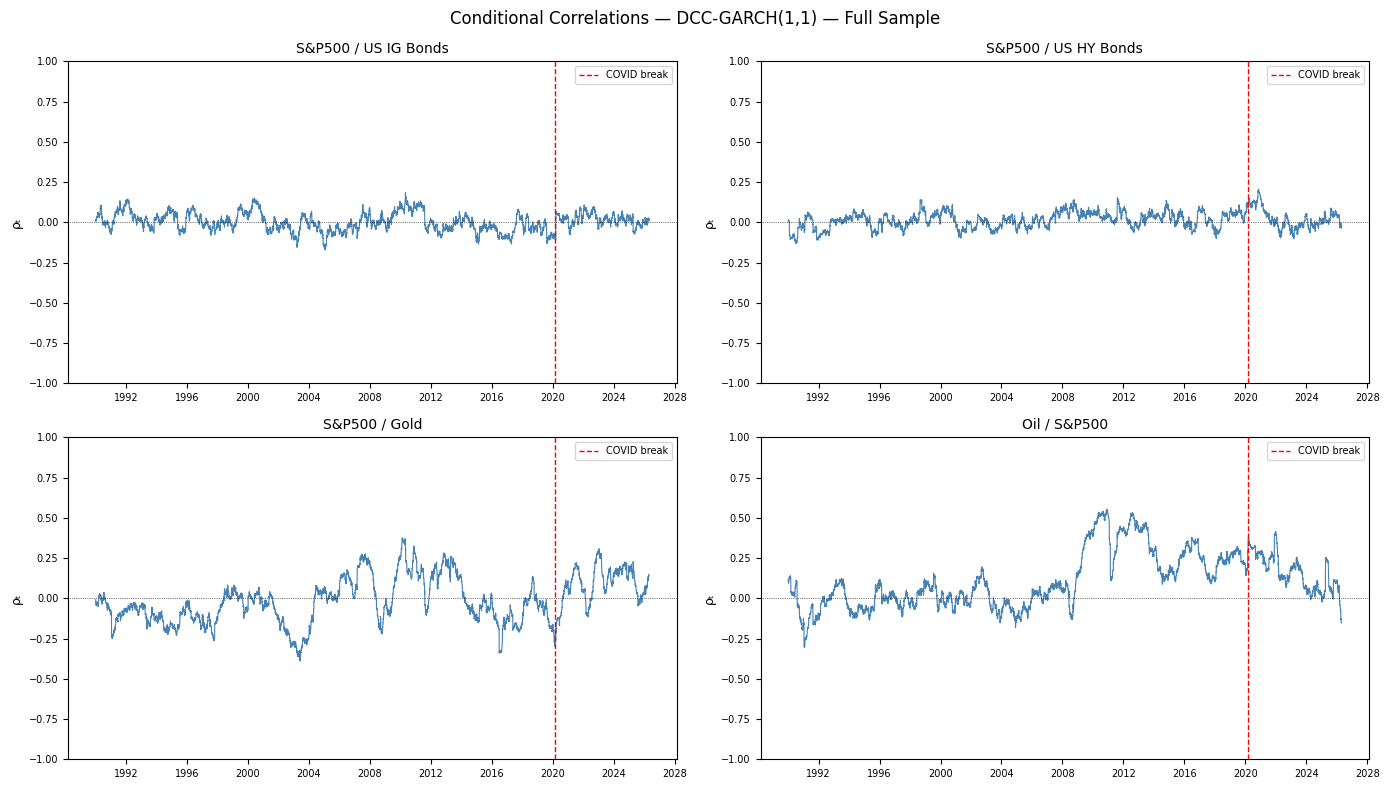

In [41]:
pairs = [
    ("S&P500",      "US IG Bonds", "S&P500 / US IG Bonds"),
    ("S&P500",      "US HY Bonds", "S&P500 / US HY Bonds"),
    ("S&P500",      "Gold",        "S&P500 / Gold"),
    ("Oil futures", "S&P500",      "Oil / S&P500"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

# Use full-sample DCC for the time series plots
Gammas = dcc_full["Gammas"]

for k, (a1, a2, title) in enumerate(pairs):
    ax  = axes[k]
    i1  = ASSETS.index(a1)
    i2  = ASSETS.index(a2)
    rho = Gammas[:, i1, i2]

    ax.plot(full_dates, rho, linewidth=0.8, color="steelblue")
    ax.axvline(pd.Timestamp("2020-02-24"), color="red", linewidth=1.0,
               linestyle="--", label="COVID break")
    ax.axhline(0, color="black", linewidth=0.5, linestyle=":")
    ax.set_title(title, fontsize=10)
    ax.set_ylabel("ρₜ", fontsize=9)
    ax.set_ylim(-1, 1)
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=7)

plt.suptitle("Conditional Correlations — DCC-GARCH(1,1) — Full Sample", fontsize=12)
plt.tight_layout()
plt.show()


### 4.5 Diversification metrics

We compare average conditional correlations pre vs post COVID for the four key pairs, and report the frequency of correlation exceeding 0.5 (a threshold above which diversification benefits begin to erode materially).

In [42]:
pairs_analysis = [
    ("S&P500",      "US IG Bonds"),
    ("S&P500",      "US HY Bonds"),
    ("S&P500",      "Gold"),
    ("Oil futures", "S&P500"),
]

rows = []
for a1, a2 in pairs_analysis:
    i1 = ASSETS.index(a1)
    i2 = ASSETS.index(a2)

    rho_pre  = dcc_pre["Gammas"][:,  i1, i2]
    rho_post = dcc_post["Gammas"][:, i1, i2]

    rows.append({
        "Pair"               : f"{a1} / {a2}",
        "ρ̄ pre"              : round(rho_pre.mean(), 3),
        "ρ̄ post"             : round(rho_post.mean(), 3),
        "Δρ̄"                 : round(rho_post.mean() - rho_pre.mean(), 3),
        "P(ρ>0.5) pre %"     : round((rho_pre  > 0.5).mean() * 100, 1),
        "P(ρ>0.5) post %"    : round((rho_post > 0.5).mean() * 100, 1),
        "P(ρ<0) pre %"       : round((rho_pre  < 0.0).mean() * 100, 1),
        "P(ρ<0) post %"      : round((rho_post < 0.0).mean() * 100, 1),
    })

div_df = pd.DataFrame(rows).set_index("Pair")
print("Diversification metrics — average conditional correlations")
print(div_df.to_string())


Diversification metrics — average conditional correlations
                      ρ̄ pre  ρ̄ post    Δρ̄  P(ρ>0.5) pre %  P(ρ>0.5) post %  P(ρ<0) pre %  P(ρ<0) post %
Pair                                                                                                      
S&P500 / US IG Bonds  -0.001    0.157  0.158             0.0              0.0          53.6            5.5
S&P500 / US HY Bonds   0.013    0.598  0.584             0.0             97.9          35.8            0.0
S&P500 / Gold         -0.039    0.144  0.184             0.0              0.0          66.2            9.2
Oil futures / S&P500   0.103    0.143  0.041             3.5              0.0          36.3            6.7


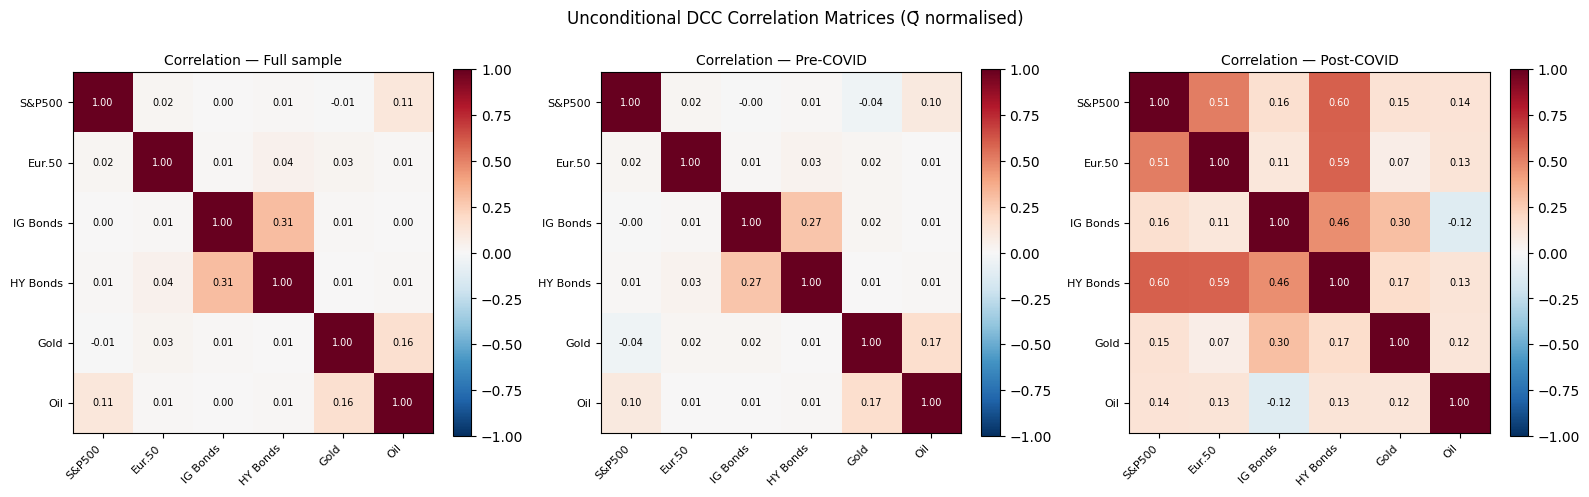

In [43]:
import matplotlib.colors as mcolors

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
titles = ["Correlation — Full sample", "Correlation — Pre-COVID", "Correlation — Post-COVID"]
# Normalise Q_bar to a proper correlation matrix before display
mats = [
    normalize_qbar(dcc_full["Q_bar"]),
    normalize_qbar(dcc_pre["Q_bar"]),
    normalize_qbar(dcc_post["Q_bar"]),
]

short = [a.replace(" futures","").replace("Eurostoxx ","Eur.").replace("US ","") for a in ASSETS]

for ax, title, mat in zip(axes, titles, mats):
    im = ax.imshow(mat, vmin=-1, vmax=1, cmap="RdBu_r")
    ax.set_xticks(range(len(ASSETS))); ax.set_xticklabels(short, rotation=45, ha="right", fontsize=8)
    ax.set_yticks(range(len(ASSETS))); ax.set_yticklabels(short, fontsize=8)
    ax.set_title(title, fontsize=10)
    for i in range(len(ASSETS)):
        for j in range(len(ASSETS)):
            ax.text(j, i, f"{mat[i,j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if abs(mat[i,j]) > 0.5 else "black")
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle("Unconditional DCC Correlation Matrices (Q̄ normalised)", fontsize=12)
plt.tight_layout()
plt.show()

### 4.6 Interpretation

**DCC parameter shifts.** Post-COVID, correlation reactivity roughly doubled ($a$: 0.0073 → 0.0198) while persistence fell ($b$: 0.9915 → 0.9552), bringing $a+b$ from 0.999 to 0.975. Correlations now respond faster to joint shocks and revert more quickly to their long-run level — the co-movement structure became more volatile but less "sticky" post-COVID.

**Equity-bond correlation (S\&P 500 / US IG Bonds).** The long-run unconditional correlation $\bar{\rho}$ shifted from essentially zero (−0.001) pre-COVID to +0.160 post-COVID. At the dynamic level, the average conditional $\rho_t$ moved from −0.001 to +0.157, and the fraction of trading days with negative correlation fell from 54% to just 6%. The equity-bond diversification relationship that supports the 60-40 portfolio **weakened substantially** post-COVID — the traditional flight-to-quality co-movement can no longer be relied upon consistently.

**Credit co-movement (S\&P 500 / US HY Bonds).** This is the largest shift. Average conditional correlation jumped from 0.013 to 0.598, and on 97.9% of post-COVID trading days the correlation exceeded 0.5. High-yield credit has become much more **equity-like** in terms of risk co-movement, severely reducing its diversification benefit. This is consistent with risk-off episodes post-COVID driving simultaneous equity and credit sell-offs through the same macro and liquidity channels.

**Gold as safe haven (S\&P 500 / Gold).** Pre-COVID, gold had a negative correlation with equities on 66% of trading days ($\bar{\rho} = -0.039$), consistent with Baur & Lucey (2010)'s safe-haven characterisation. Post-COVID, that fraction dropped to 9% and $\bar{\rho}$ rose to +0.144. **Caution:** the pre-COVID GJR-GARCH diagnostics for Gold are weaker (LB(z²)/ARCH-LM borderline), so the DCC-based safe-haven result for the pre-COVID period should be interpreted cautiously and cross-checked with static or rolling correlations before drawing firm conclusions.

**Oil-equity link.** The oil-S\&P 500 average correlation rose modestly from 0.103 to 0.143 — the smallest shift among the four pairs. The April 2020 oil price collapse (WTI briefly negative) appears as a spike in the full-sample correlation path, but the structural relationship is relatively stable across regimes.

**Overall Q̄ shift.** The post-COVID normalised Q̄ shows near-uniformly higher correlations. Pre-COVID, most off-diagonal entries were near zero; post-COVID, S\&P 500 / Eurostoxx (~0.51), S\&P 500 / HY Bonds (~0.60), and IG Bonds / HY Bonds (~0.46) are the dominant pairs. A single common factor — likely the global risk-on/risk-off cycle — accounts for more of the variance in co-movement post-COVID (cf. the PCA finding: PC1 share +10.7 pp). Multi-asset diversification has become harder.

**Literature anchor:** Engle (2002) for DCC. Forbes & Rigobon (2002) for conditional correlation bias in static estimates. Baur & Lucey (2010) for gold as safe haven — their finding holds pre-COVID but weakens post-COVID in our sample. Engle & Sheppard (2001) for DCC two-step estimation.

## Part 5 — Structural break tests (forthcoming)

The LR test below formally verifies whether GARCH parameters changed significantly at the COVID-19 breakpoint.

**Likelihood-Ratio (LR) structural break test.**

For each asset, the restricted model (H₀) is the full-sample GJR-GARCH. The unrestricted model (H₁) fits separate parameters for pre- and post-COVID. If the regime is truly constant, the combined pre+post log-likelihood should not exceed the full-sample log-likelihood by more than sampling variation.

$$LR = 2\,(LL_{\text{pre}} + LL_{\text{post}} - LL_{\text{full}}) \sim \chi^2(k)$$

where $k$ is the number of free GJR-GARCH parameters per period (7 for GJR-GARCH(1,1) with Student-t and AR(1): $\mu$, AR(1), $\omega$, $\alpha$, $\gamma$, $\beta$, $\nu$).

A significant LR (p < 0.05) provides formal statistical evidence of a parameter regime change at the COVID breakpoint.

In [44]:
# LR structural break test — GJR-GARCH(1,1) Student-t
# k = 7 parameters per period (mu, ar1, omega, alpha, gamma, beta, nu)
from scipy.stats import chi2 as scipy_chi2

K = 7  # free parameters in GJR-GARCH(1,1) + AR(1) + Student-t

print("LR structural break test  H0: single regime  vs  H1: pre/post separate regimes")
print(f"LR = 2 (LL_pre + LL_post - LL_full)  ~  chi2({K})")
print()
print(f"{'Asset':<20} {'LL full':>10} {'LL pre':>10} {'LL post':>10} {'LR stat':>10} {'p-value':>10} {'Reject H0':>10}")
print("-" * 84)

for col in ASSETS:
    ll_full = fits_full_t[col]["loglik"]
    ll_pre  = fits_pre_t[col]["loglik"]
    ll_post = fits_post_t[col]["loglik"]
    lr_stat = 2 * (ll_pre + ll_post - ll_full)
    p_val   = 1 - scipy_chi2.cdf(lr_stat, df=K)
    reject  = p_val < 0.05
    print(f"{col:<20} {ll_full:>10.1f} {ll_pre:>10.1f} {ll_post:>10.1f} "
          f"{lr_stat:>10.1f} {p_val:>10.4f} {'Yes ***' if reject else 'No':>10}")

print()
print("Interpretation: significant LR (p < 0.05) = GARCH parameters changed at the COVID breakpoint.")
print("This provides formal statistical motivation for the pre/post split used throughout this notebook.")

LR structural break test  H0: single regime  vs  H1: pre/post separate regimes
LR = 2 (LL_pre + LL_post - LL_full)  ~  chi2(7)

Asset                   LL full     LL pre    LL post    LR stat    p-value  Reject H0
------------------------------------------------------------------------------------
S&P500                 -12088.3    -9862.5    -2213.6       24.3     0.0010    Yes ***
Eurostoxx 50           -13931.7   -11602.9    -2316.1       25.4     0.0006    Yes ***
US IG Bonds            -23559.8   -19194.3     -586.2     7558.5     0.0000    Yes ***
US HY Bonds            -17674.8   -13990.6      116.9     7602.2     0.0000    Yes ***
Gold                   -11797.0    -9520.7    -2252.3       48.1     0.0000    Yes ***
Oil futures            -20363.6   -16652.1    -3678.7       65.7     0.0000    Yes ***

Interpretation: significant LR (p < 0.05) = GARCH parameters changed at the COVID breakpoint.
This provides formal statistical motivation for the pre/post split used throughout 

In [45]:
def run_dcc_diagnostics(dcc_result, label):
    a = dcc_result["a"]
    b = dcc_result["b"]
    Gammas = dcc_result["Gammas"]
    Q_bar = dcc_result["Q_bar"]

    eigvals = np.linalg.eigvalsh(Q_bar)

    checks = {
        "label": label,
        "a_nonnegative": a >= 0,
        "b_nonnegative": b >= 0,
        "stationary": a + b < 1,
        "corr_min": np.nanmin(Gammas),
        "corr_max": np.nanmax(Gammas),
        "corr_in_bounds": (np.nanmin(Gammas) >= -1.0001) and (np.nanmax(Gammas) <= 1.0001),
        "qbar_posdef": np.min(eigvals) > 0,
        "a_plus_b": a + b,
    }

    checks["dcc_pass"] = (
        checks["a_nonnegative"]
        and checks["b_nonnegative"]
        and checks["stationary"]
        and checks["corr_in_bounds"]
        and checks["qbar_posdef"]
    )

    print(f"\nDCC diagnostics — {label}")
    for k, v in checks.items():
        print(f"{k}: {v}")

    return pd.DataFrame([checks])

In [46]:
dcc_diag = pd.concat([
    run_dcc_diagnostics(dcc_full, "Full"),
    run_dcc_diagnostics(dcc_pre, "Pre-COVID"),
    run_dcc_diagnostics(dcc_post, "Post-COVID")
], ignore_index=True)

dcc_diag


DCC diagnostics — Full
label: Full
a_nonnegative: True
b_nonnegative: True
stationary: True
corr_min: -0.3893597490363242
corr_max: 1.0
corr_in_bounds: True
qbar_posdef: True
a_plus_b: 0.99847
dcc_pass: True

DCC diagnostics — Pre-COVID
label: Pre-COVID
a_nonnegative: True
b_nonnegative: True
stationary: True
corr_min: -0.4033087791567123
corr_max: 1.0
corr_in_bounds: True
qbar_posdef: True
a_plus_b: 0.99879
dcc_pass: True

DCC diagnostics — Post-COVID
label: Post-COVID
a_nonnegative: True
b_nonnegative: True
stationary: True
corr_min: -0.38923900590279165
corr_max: 1.0
corr_in_bounds: True
qbar_posdef: True
a_plus_b: 0.97498
dcc_pass: True


,label,a_nonnegative,b_nonnegative,stationary,corr_min,corr_max,corr_in_bounds,qbar_posdef,a_plus_b,dcc_pass
0,Full,True,True,True,-0.389360,1.0,True,True,0.99847,True
1,Pre-COVID,True,True,True,-0.403309,1.0,True,True,0.99879,True
2,Post-COVID,True,True,True,-0.389239,1.0,True,True,0.97498,True
